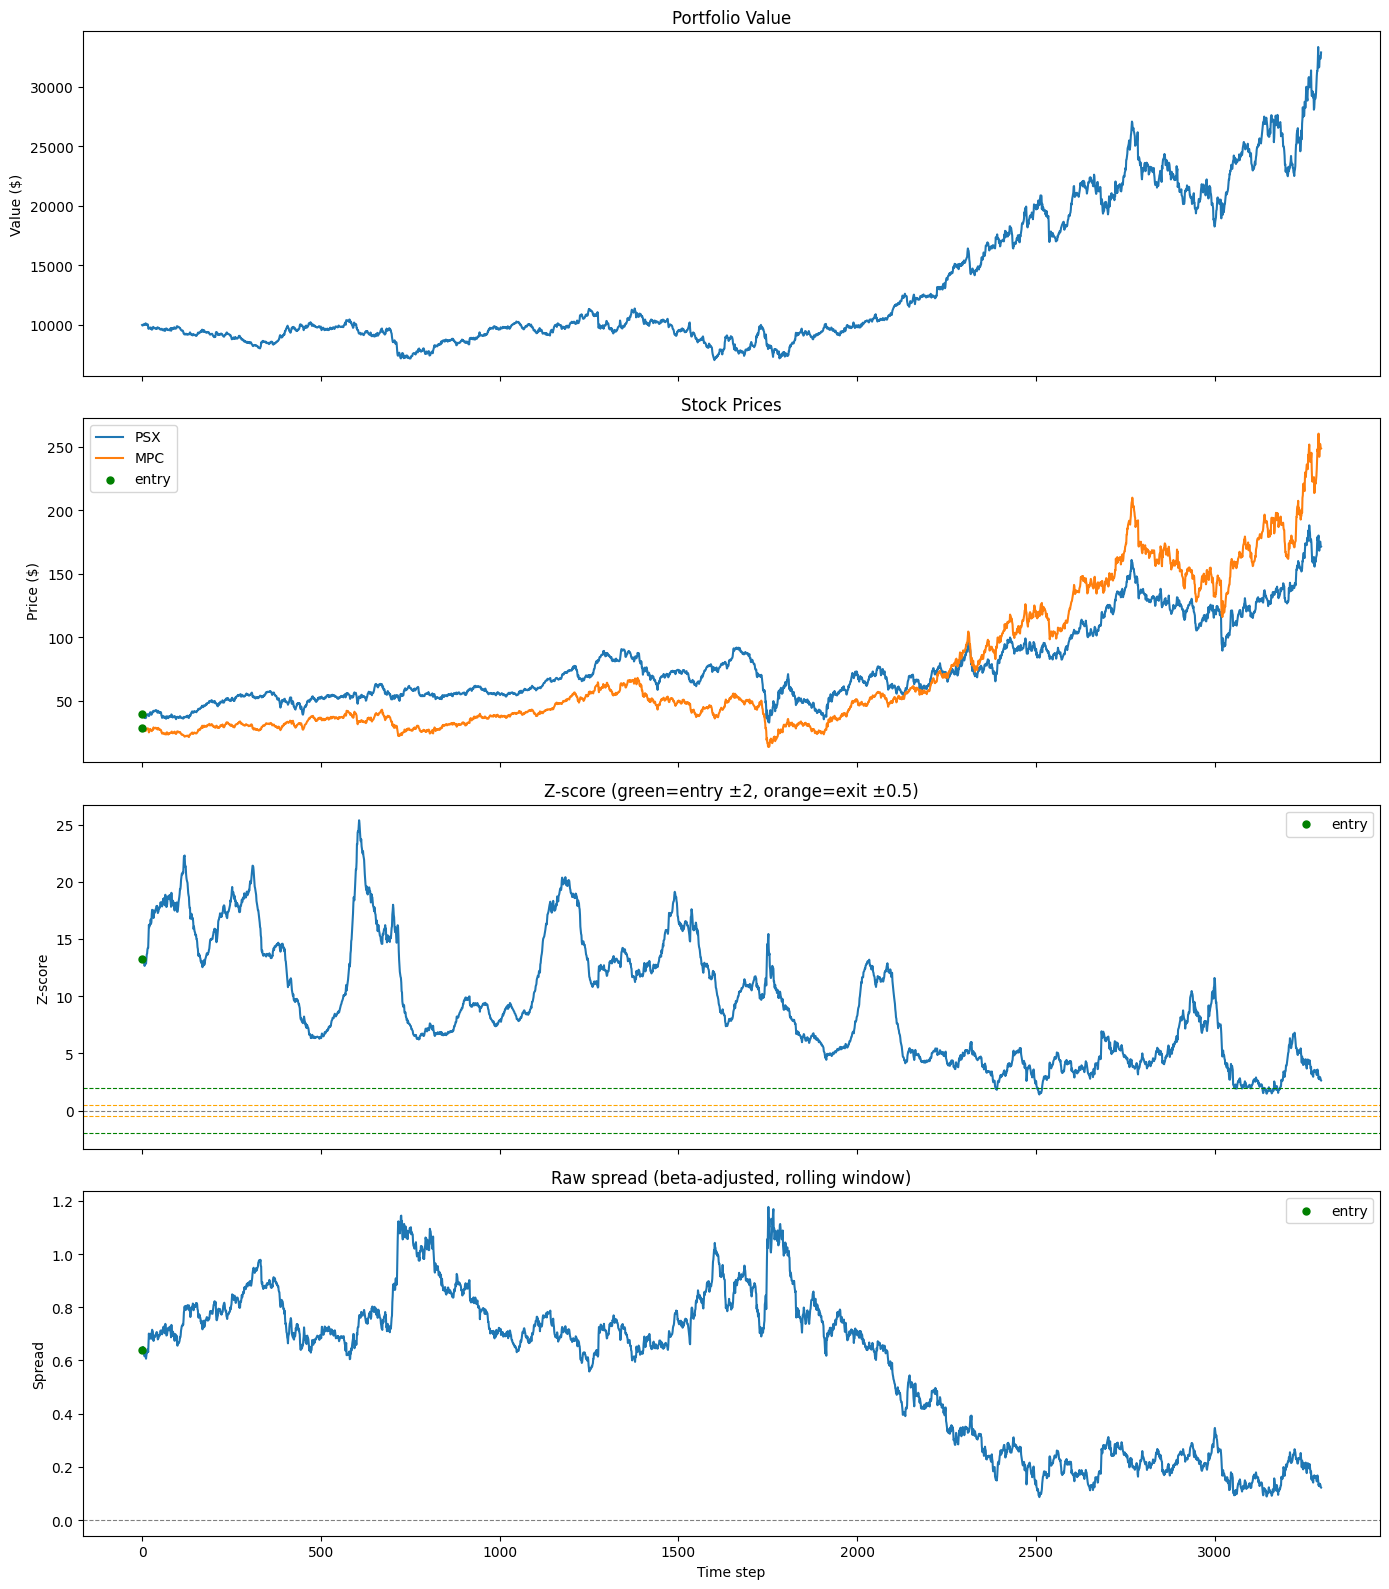

In [1]:
import sys
sys.path.append("../")

from env import Market, Actions
from data_loader import PairData
from static_thresh_base import ZScoreBaseline
from runner import run_strategy, plot_strategy

pair_data = PairData("../../data/real_pair_PSX_MPC.csv")
env = Market(pair_data, past_window=200)
agent = ZScoreBaseline(entry_threshold=2.0, exit_threshold=0.5)

results = run_strategy(env, agent)
plot_strategy(results)


PSX/MPC: β=1.7630


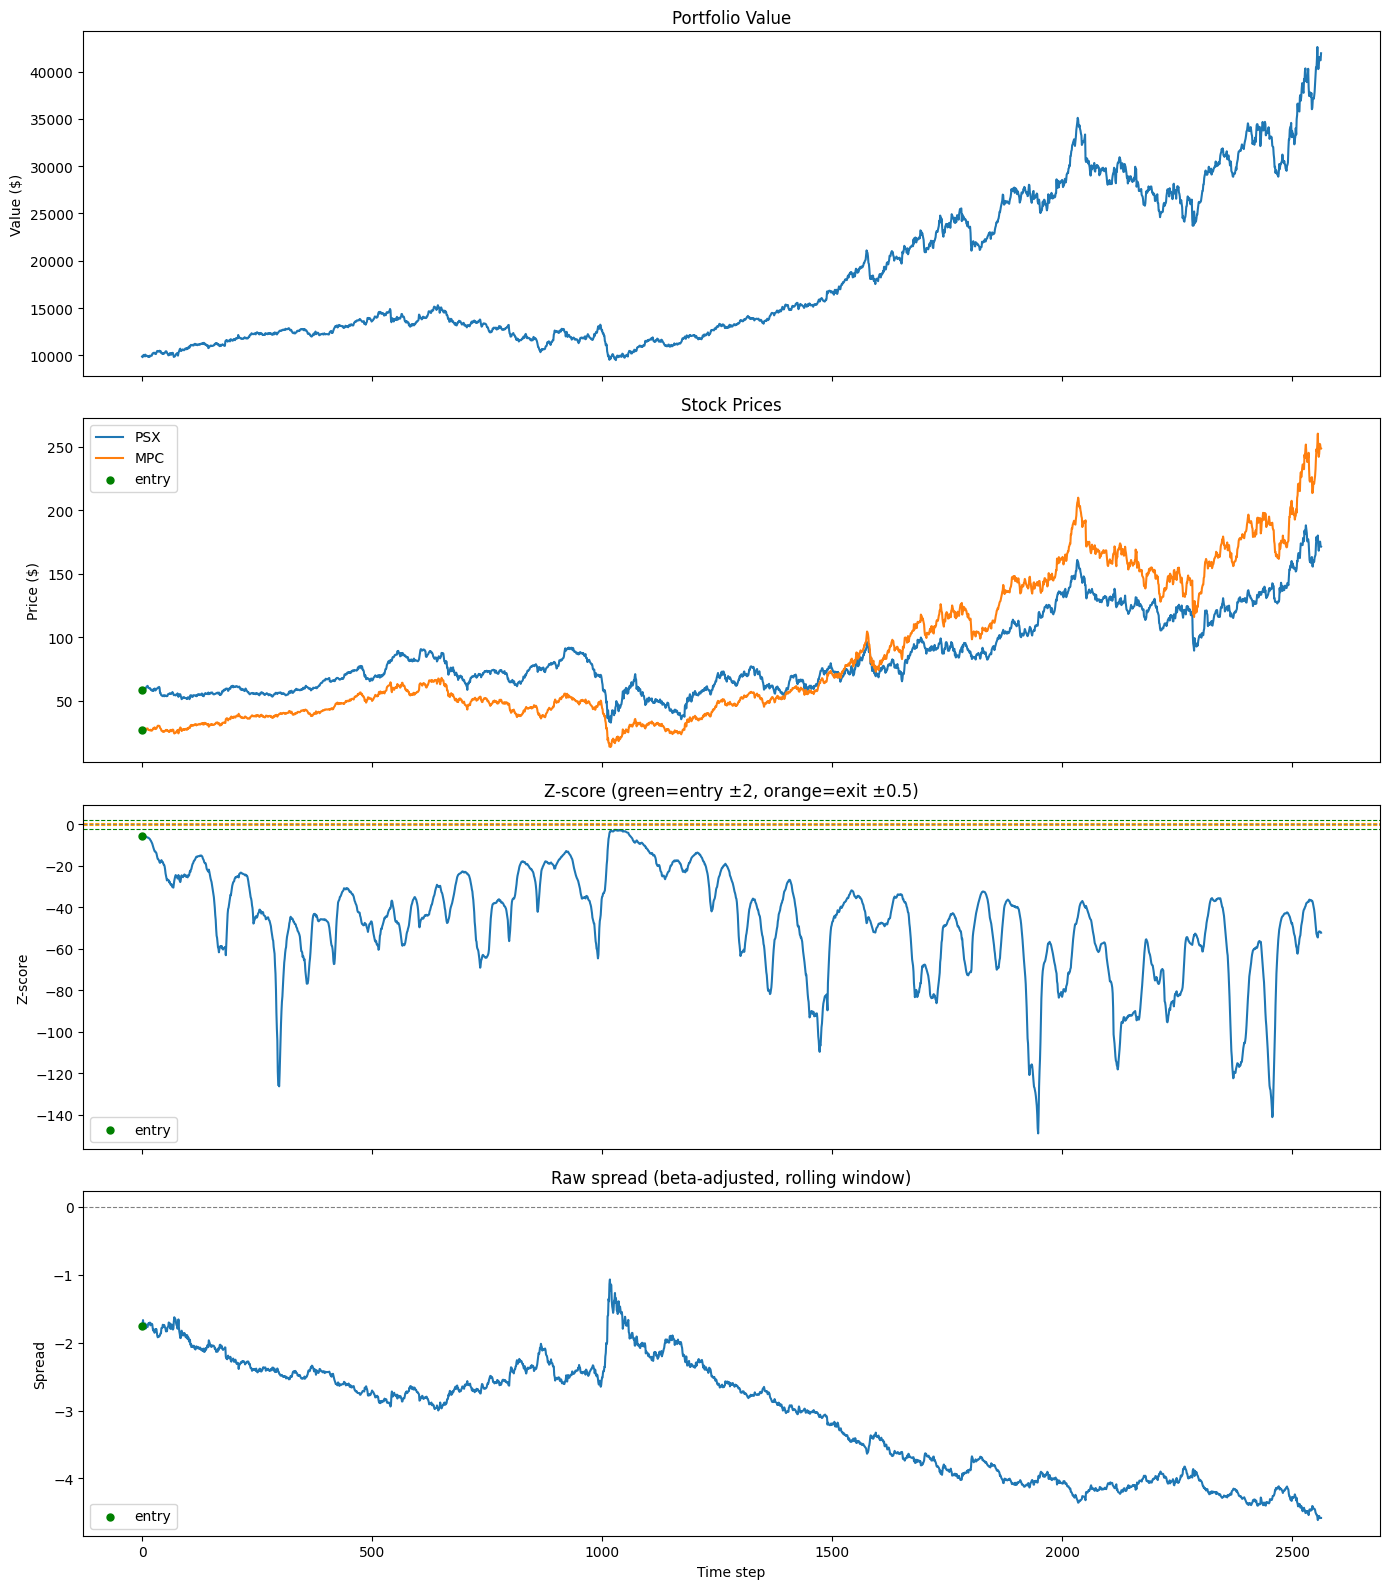

{'pnl': array([ 9878.0058562 ,  9802.1322641 ,  9981.93042069, ...,
        41208.55031091, 41185.24216691, 41928.75618388], shape=(2564,)),
 's0': array([ 58.83573914,  59.95373535,  58.16355896, ..., 175.42999268,
        171.82000732, 171.50999451], shape=(2564,)),
 's1': array([ 27.18716431,  27.04043961,  25.80066681, ..., 251.99000549,
        249.08999634, 248.82000732], shape=(2564,)),
 'spreads': array([-1.74783993, -1.7194761 , -1.66704917, ..., -4.58082247,
        -4.58120871, -4.58110237], shape=(2564,)),
 'zscores': array([ -5.62652254,  -5.56974125,  -5.42298365, ..., -51.74422836,
        -51.7750473 , -52.18679428], shape=(2564,)),
 'entries': [0],
 'exits': [],
 'labels': ['PSX', 'MPC']}

In [2]:
import numpy as np
from statsmodels.tsa.vector_ar.vecm import coint_johansen

def run_johansen_fixed_beta(pair_data):
    train_end = len(pair_data) // 4
    jres = coint_johansen(pair_data.s[:, :train_end].T, det_order=0, k_ar_diff=1)
    cv = jres.evec[:, 0]
    beta_fixed = -cv[1] / cv[0]
    print(f"{pair_data.labels[0]}/{pair_data.labels[1]}: β={beta_fixed:.4f}")
    test_data = pair_data.slice(train_end)
    env_fixed = Market(test_data, fixed_beta=beta_fixed)
    results = run_strategy(env_fixed, ZScoreBaseline(entry_threshold=2.0, exit_threshold=0.5))
    plot_strategy(results)
    return results

run_johansen_fixed_beta(pair_data)


MPC/PSX: β=0.5716


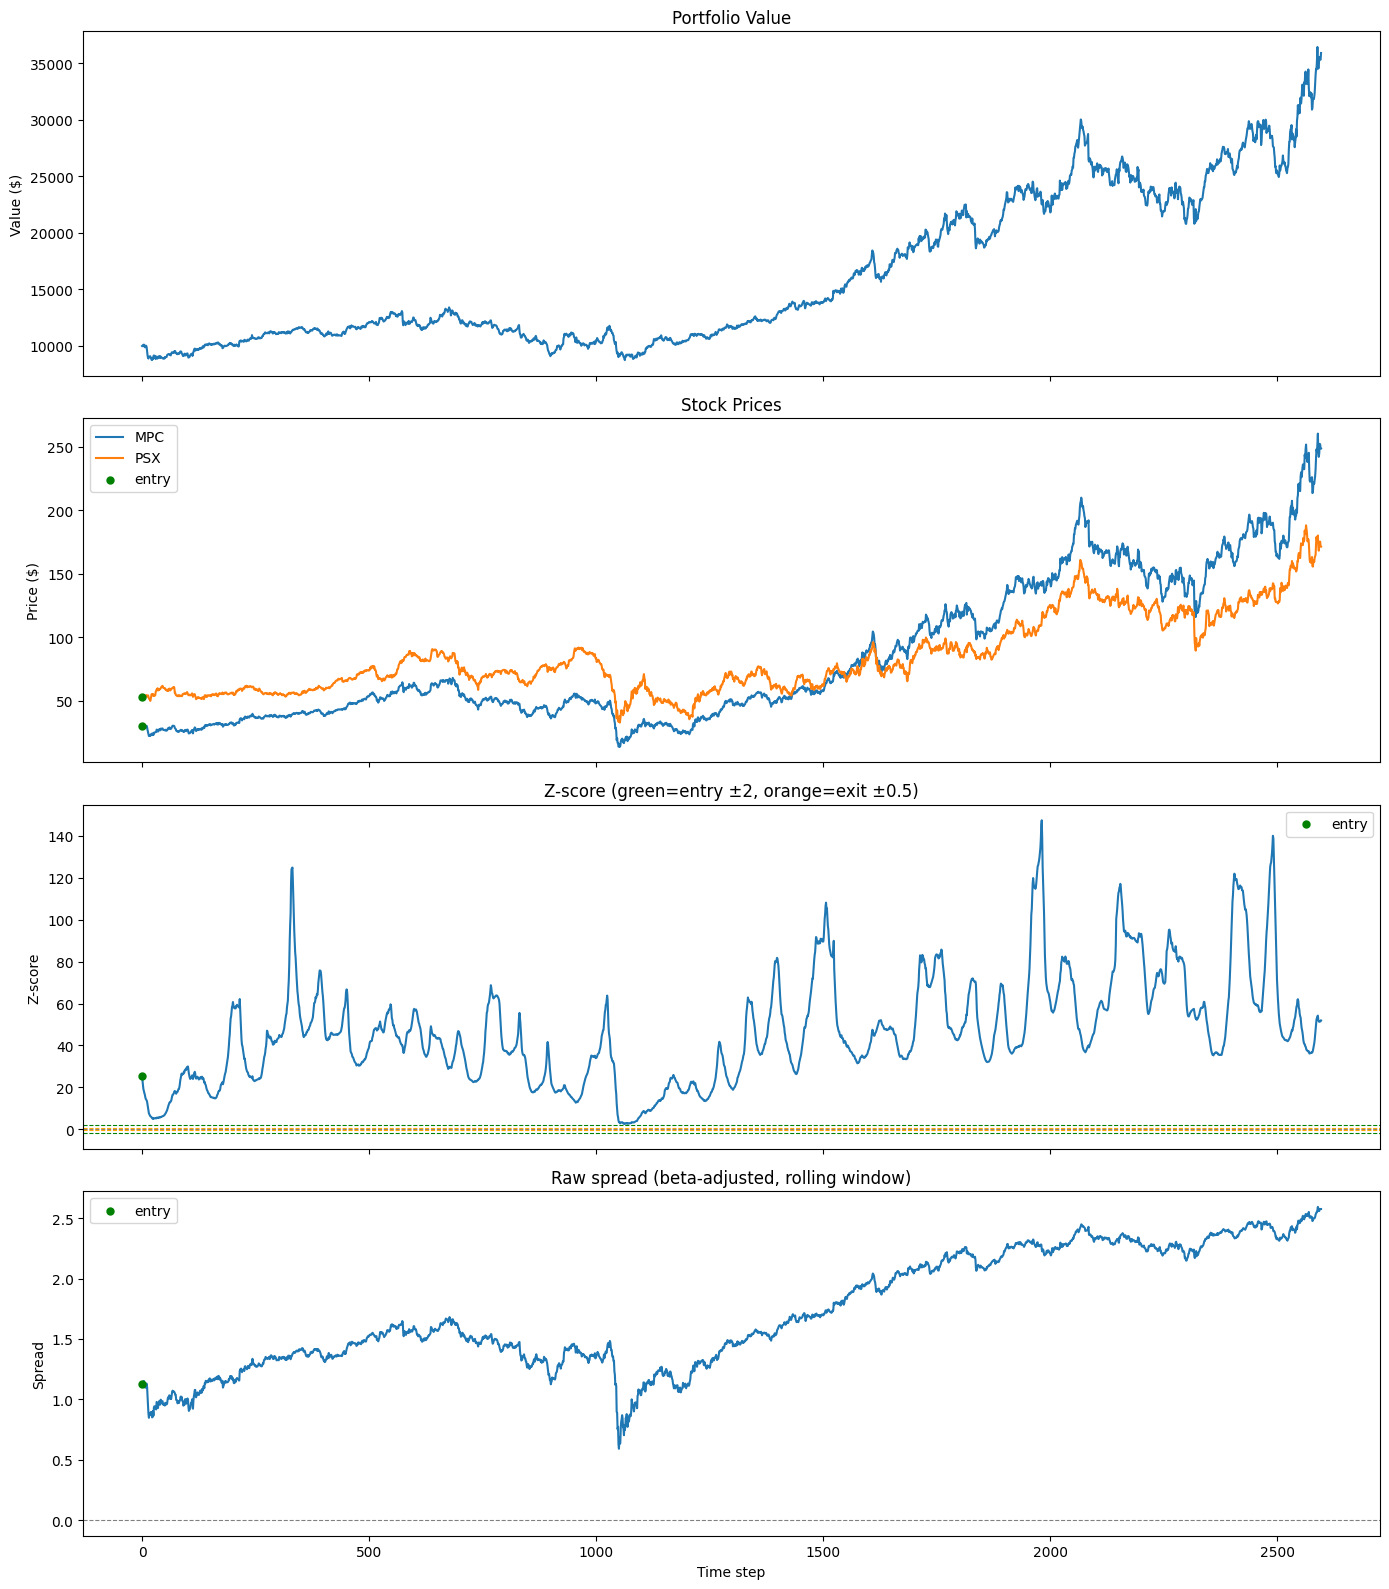

PEP/KO: β=1.2078


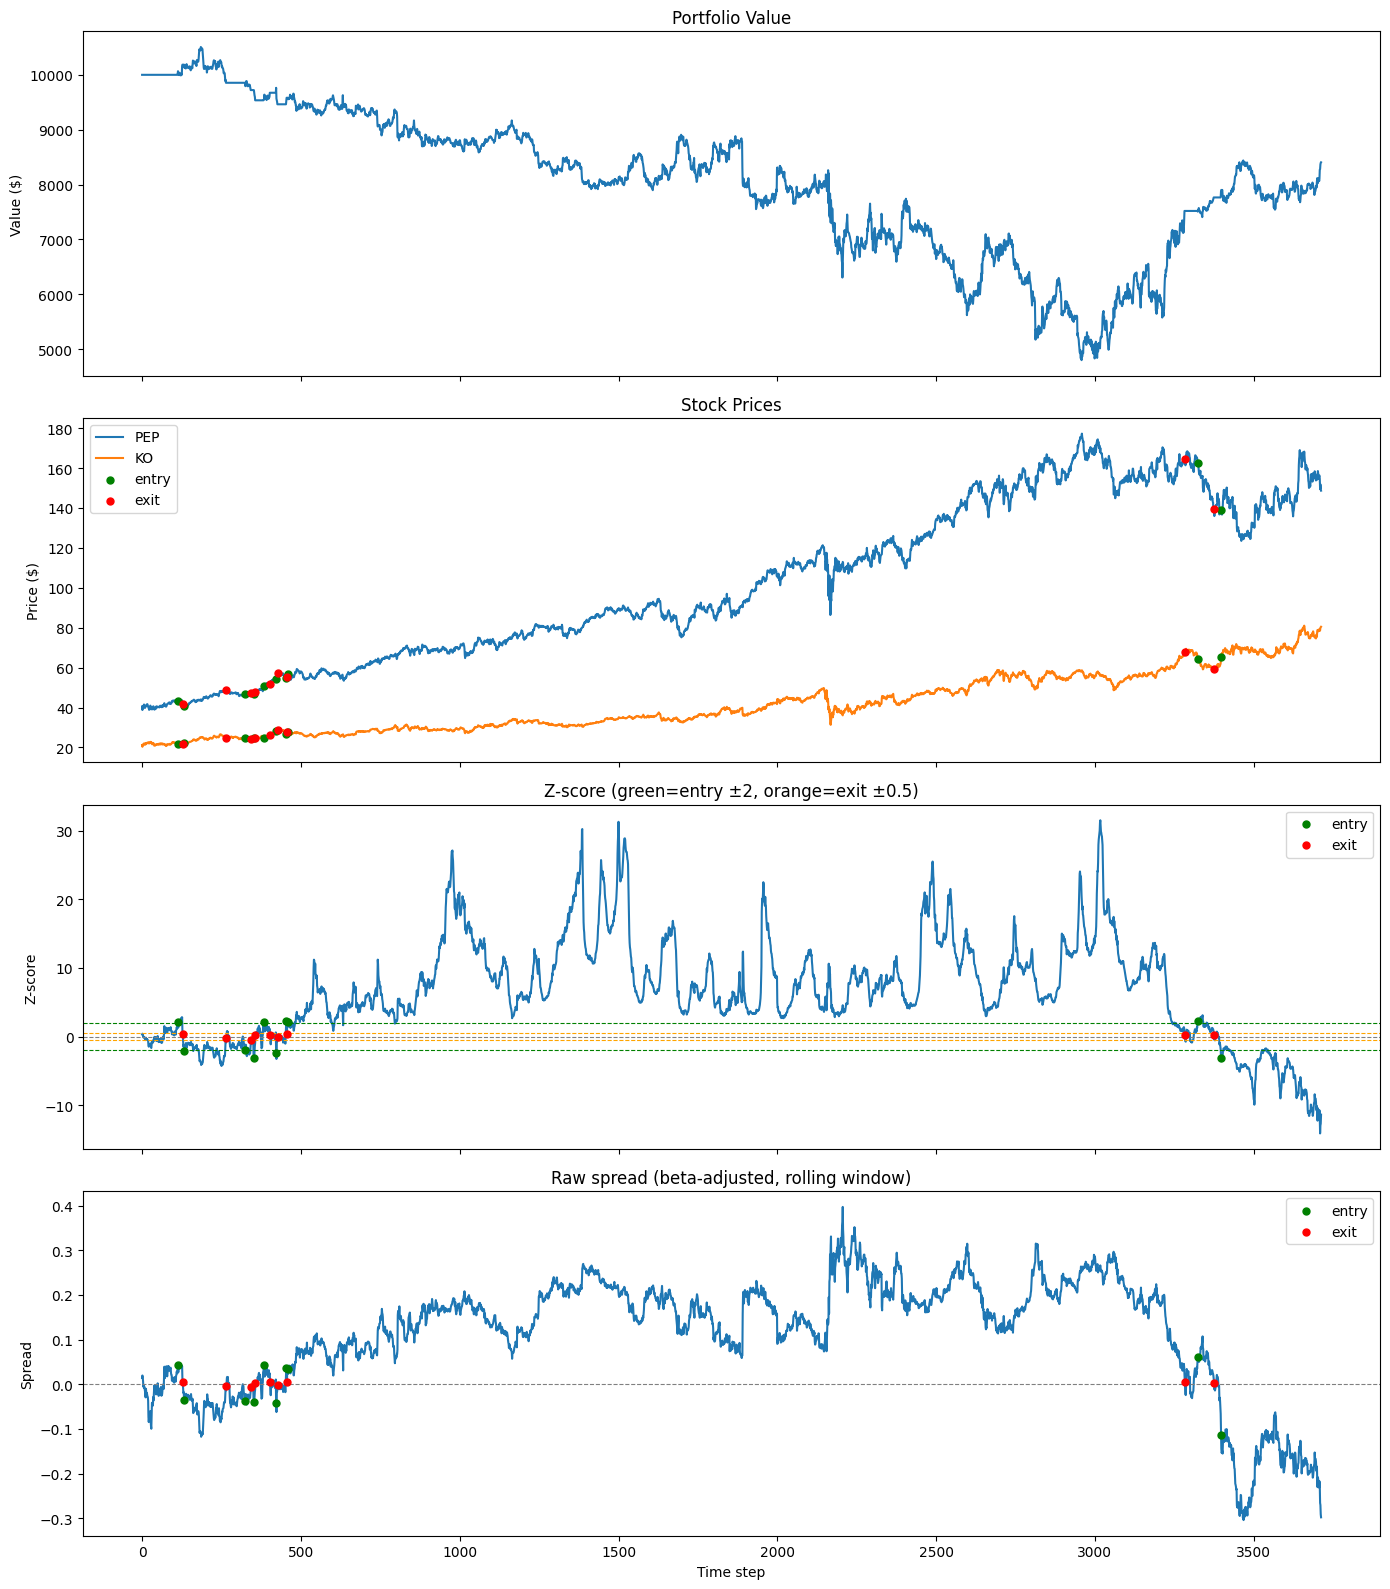

AAPL/MSFT: β=6.7941


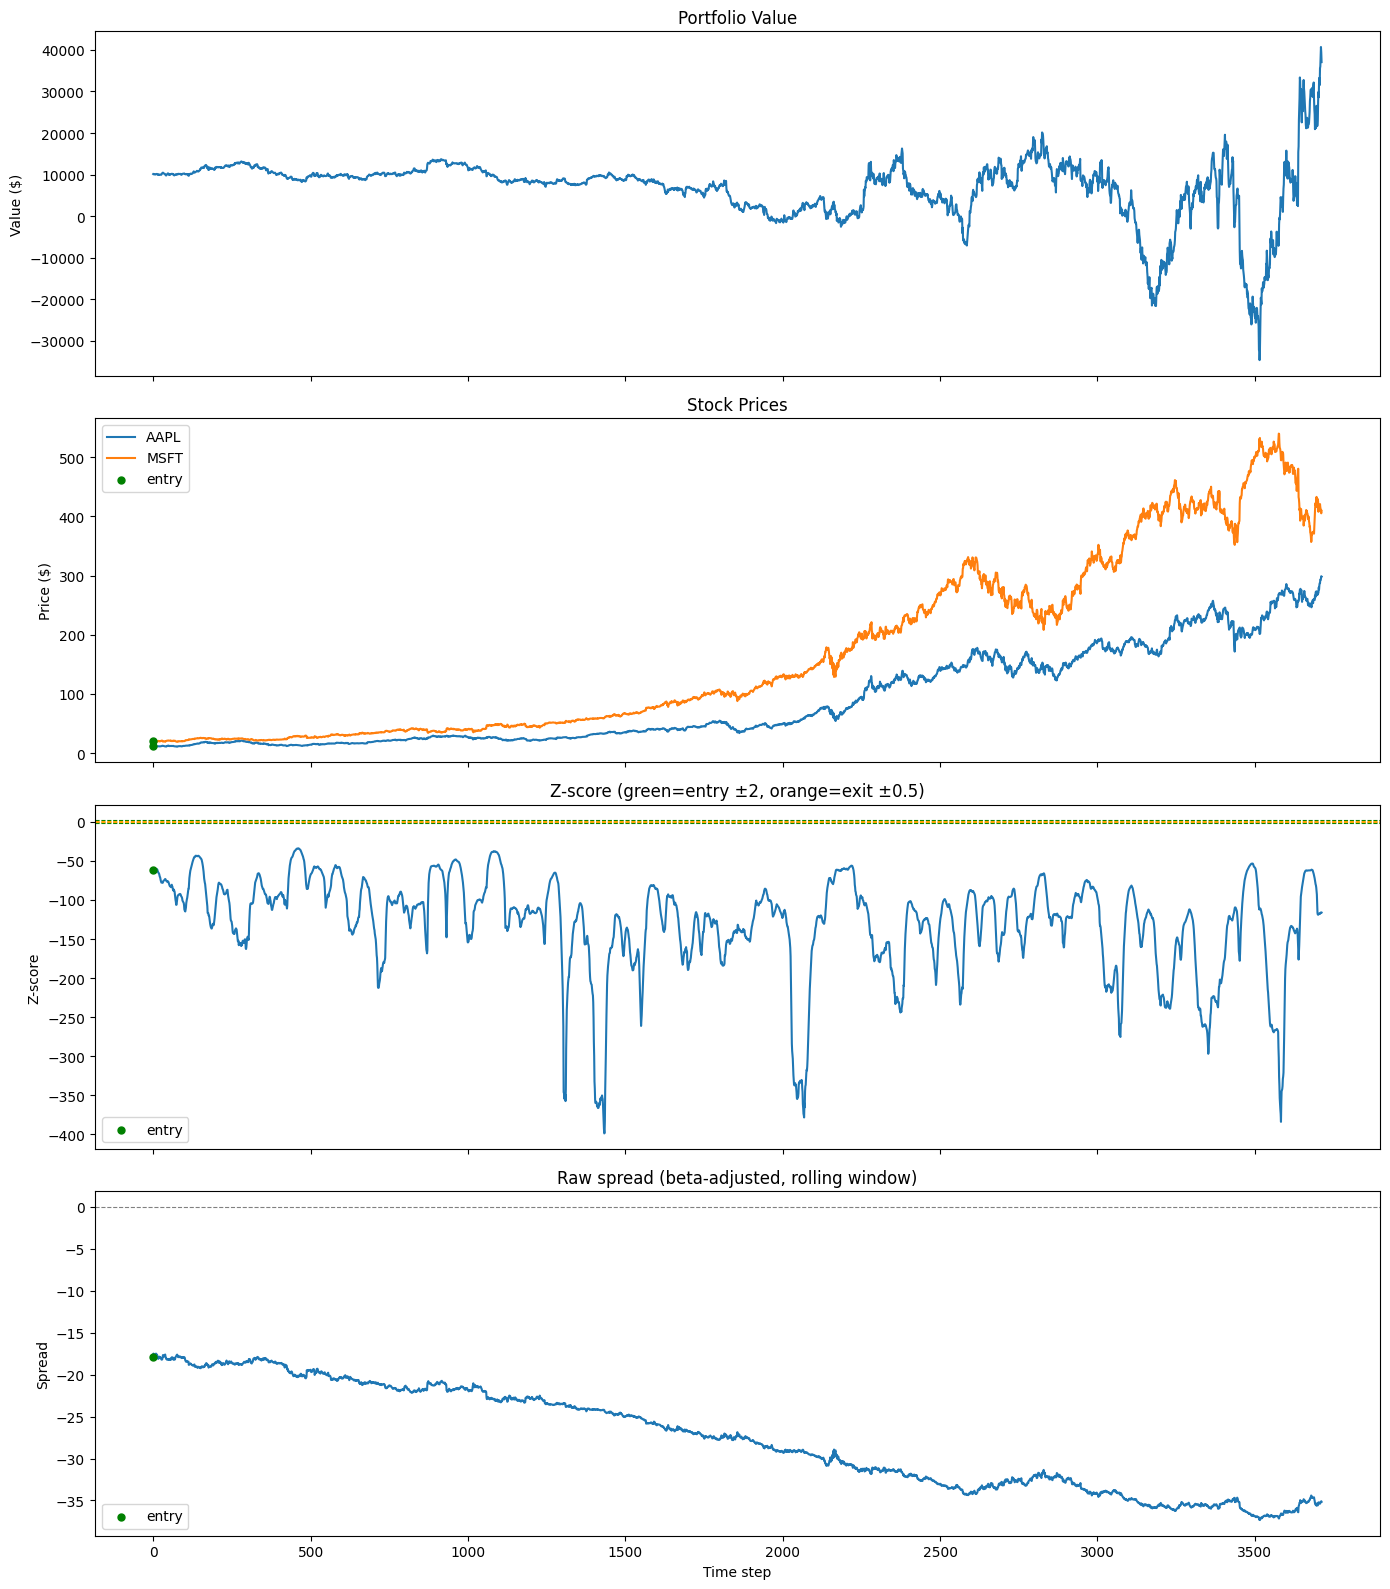

JPM/BAC: β=0.0945


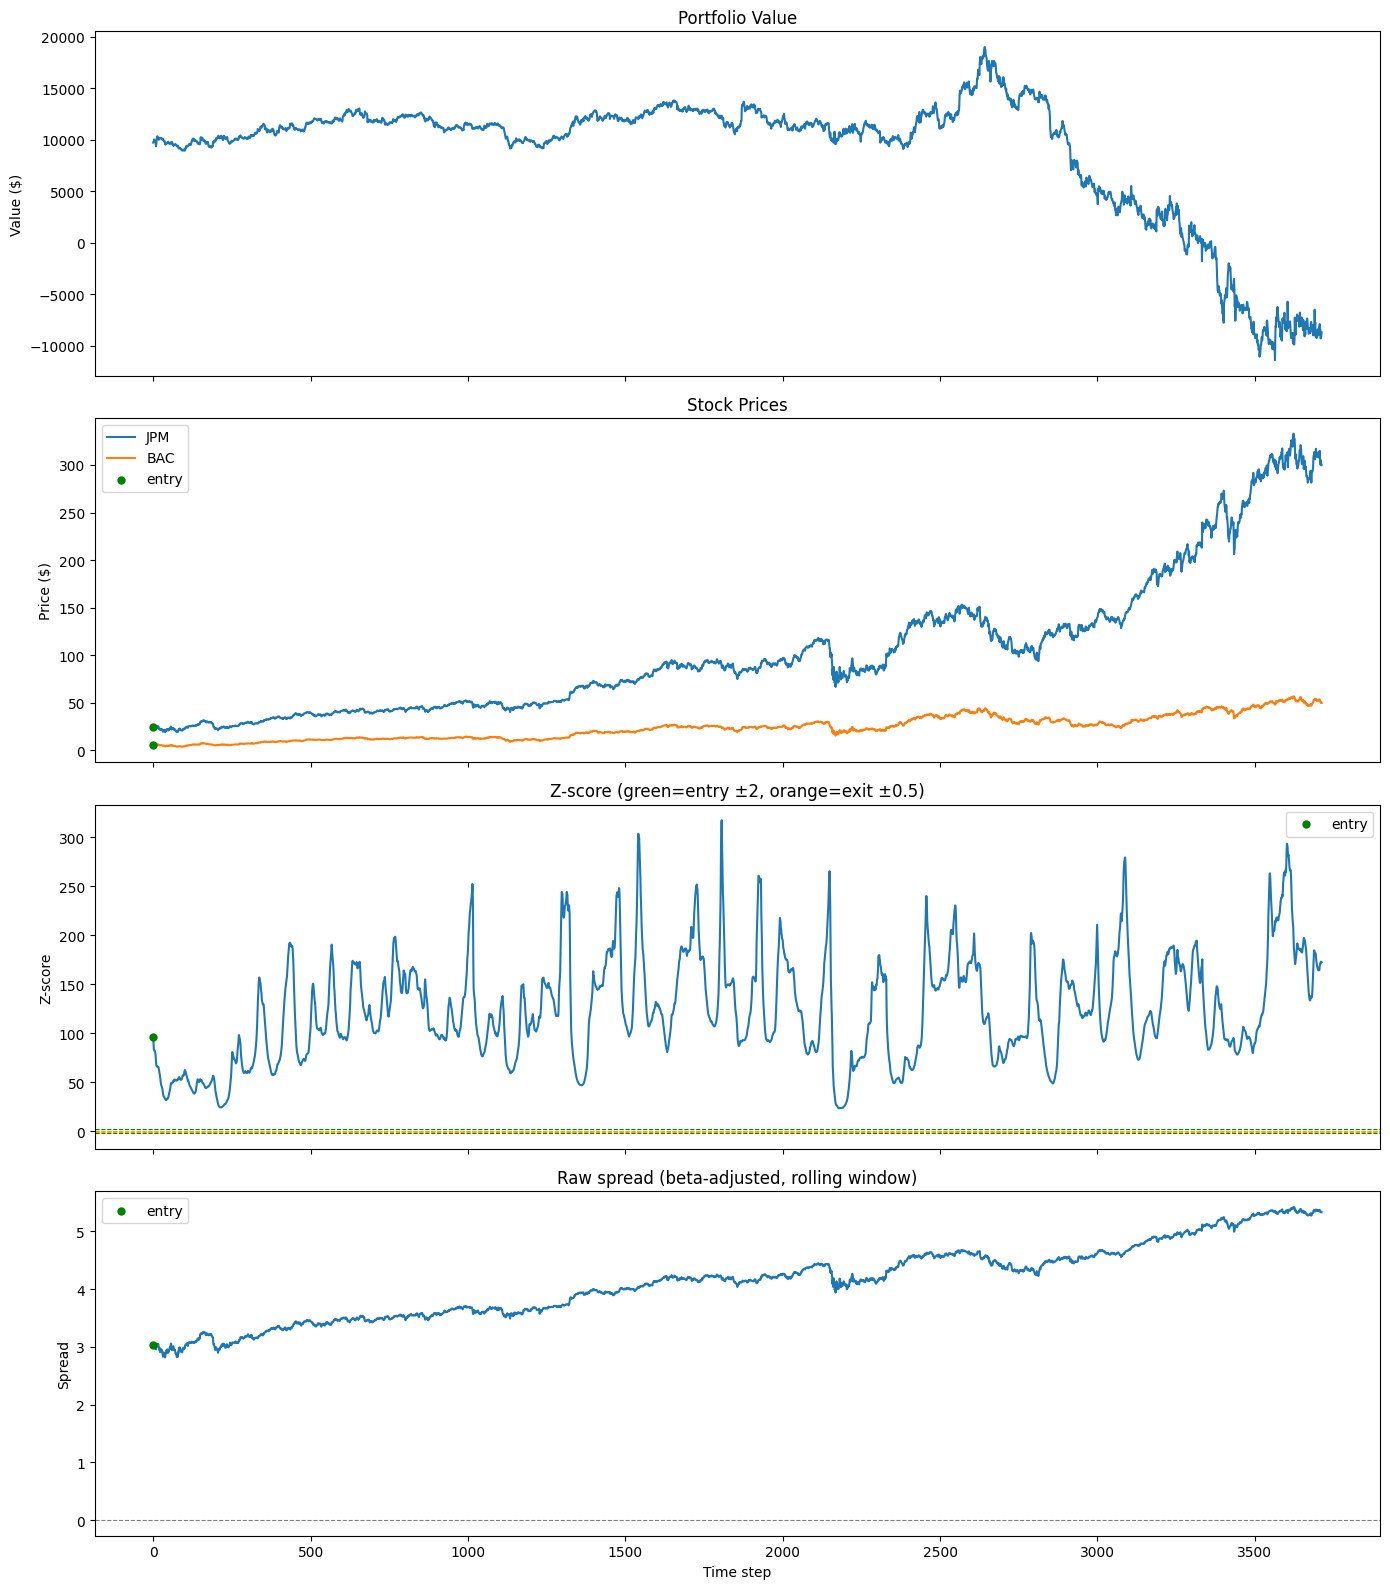

XOM/CVX: β=0.1589


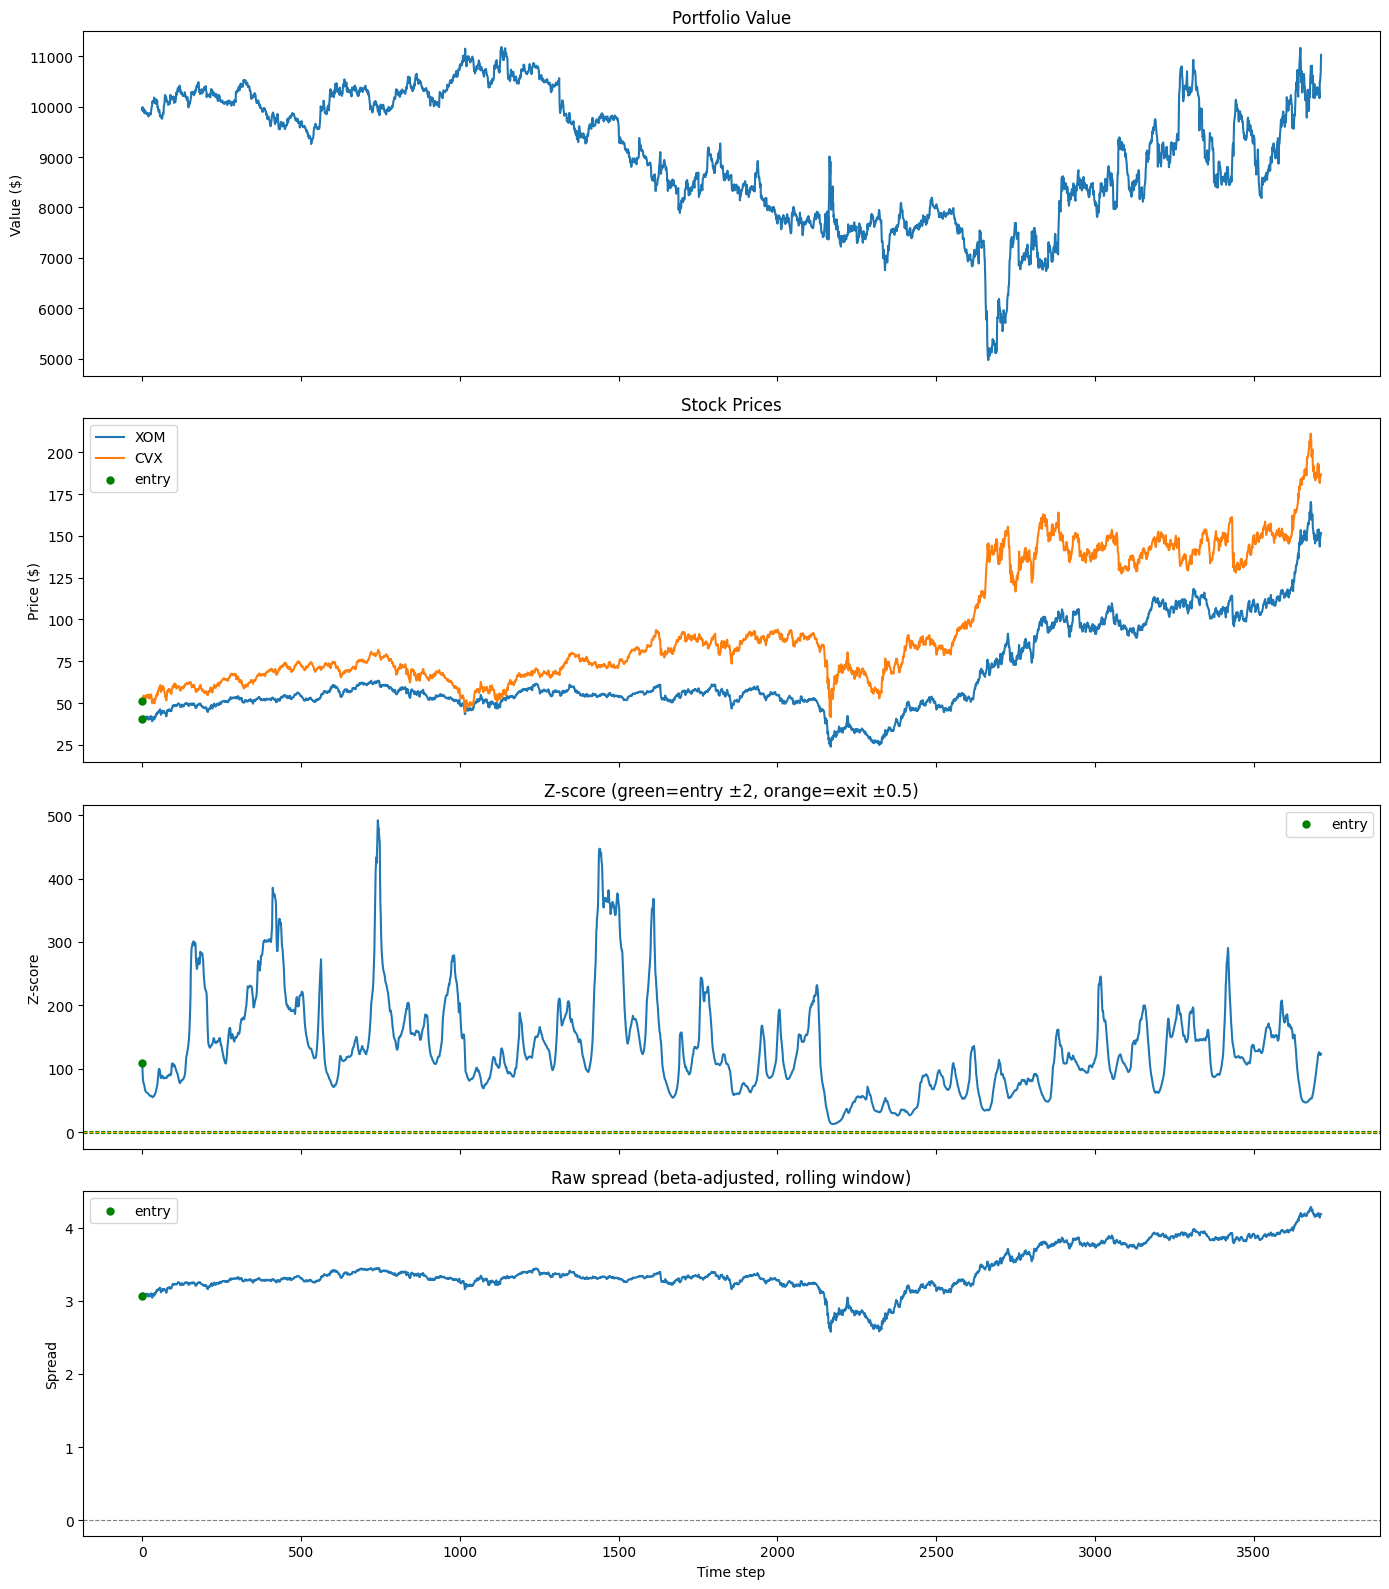

MCD/YUM: β=1.9029


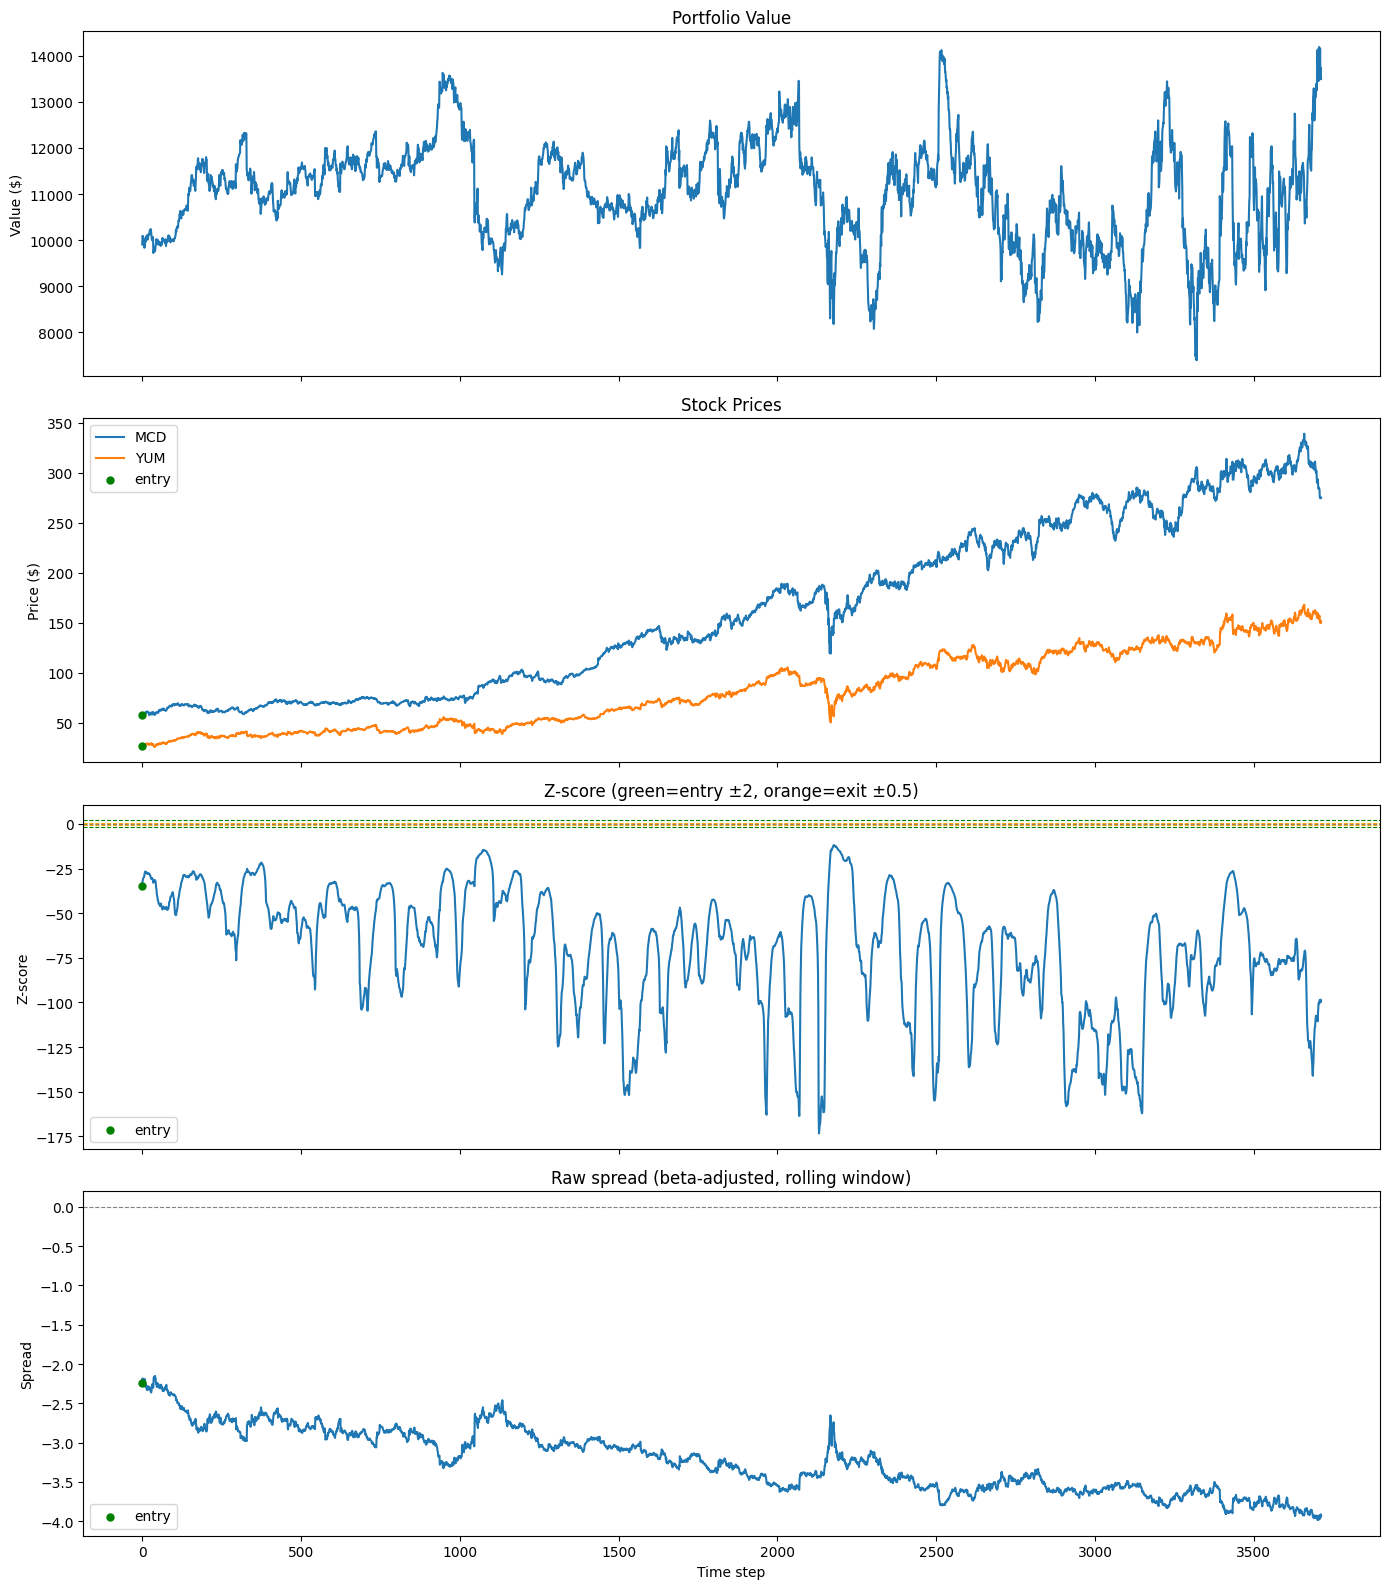

GS/MS: β=1.5863


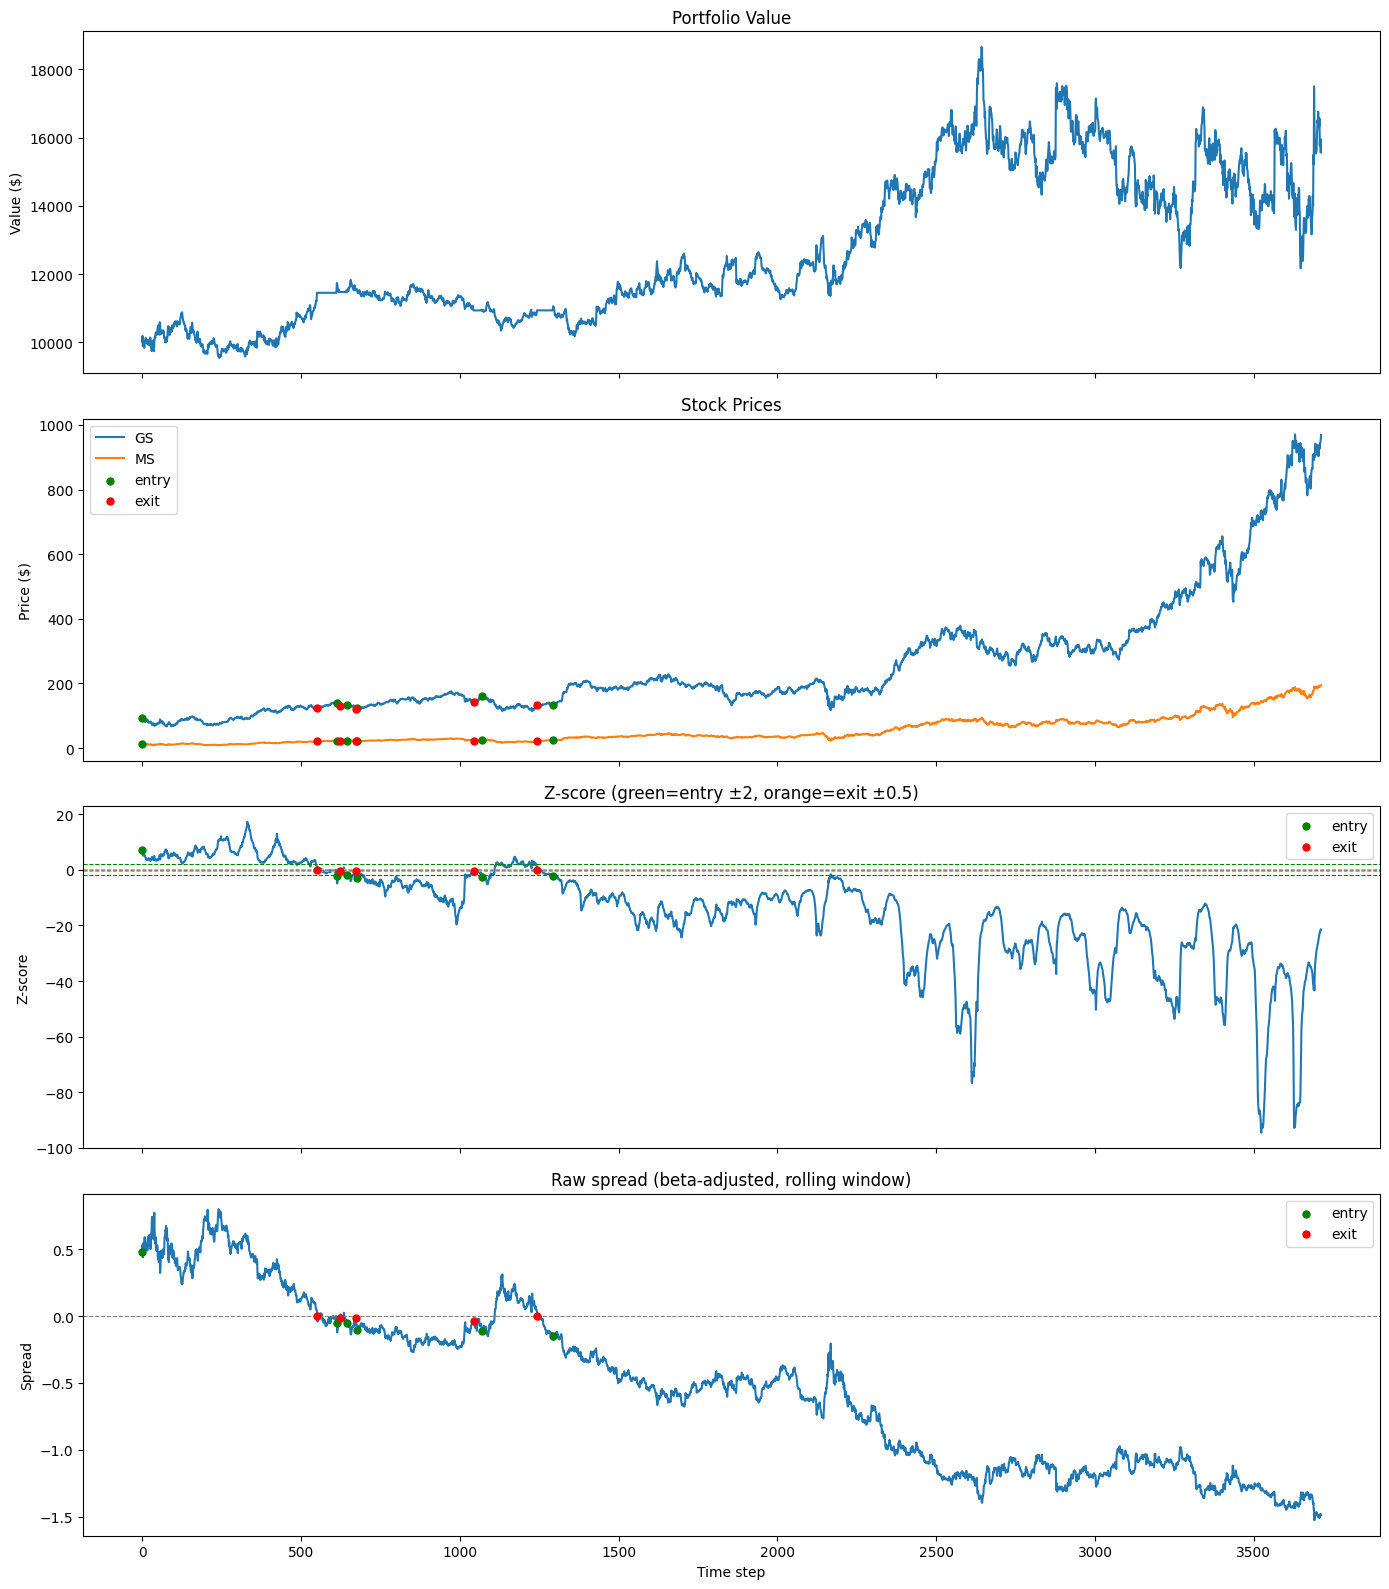

V/MA: β=0.6143


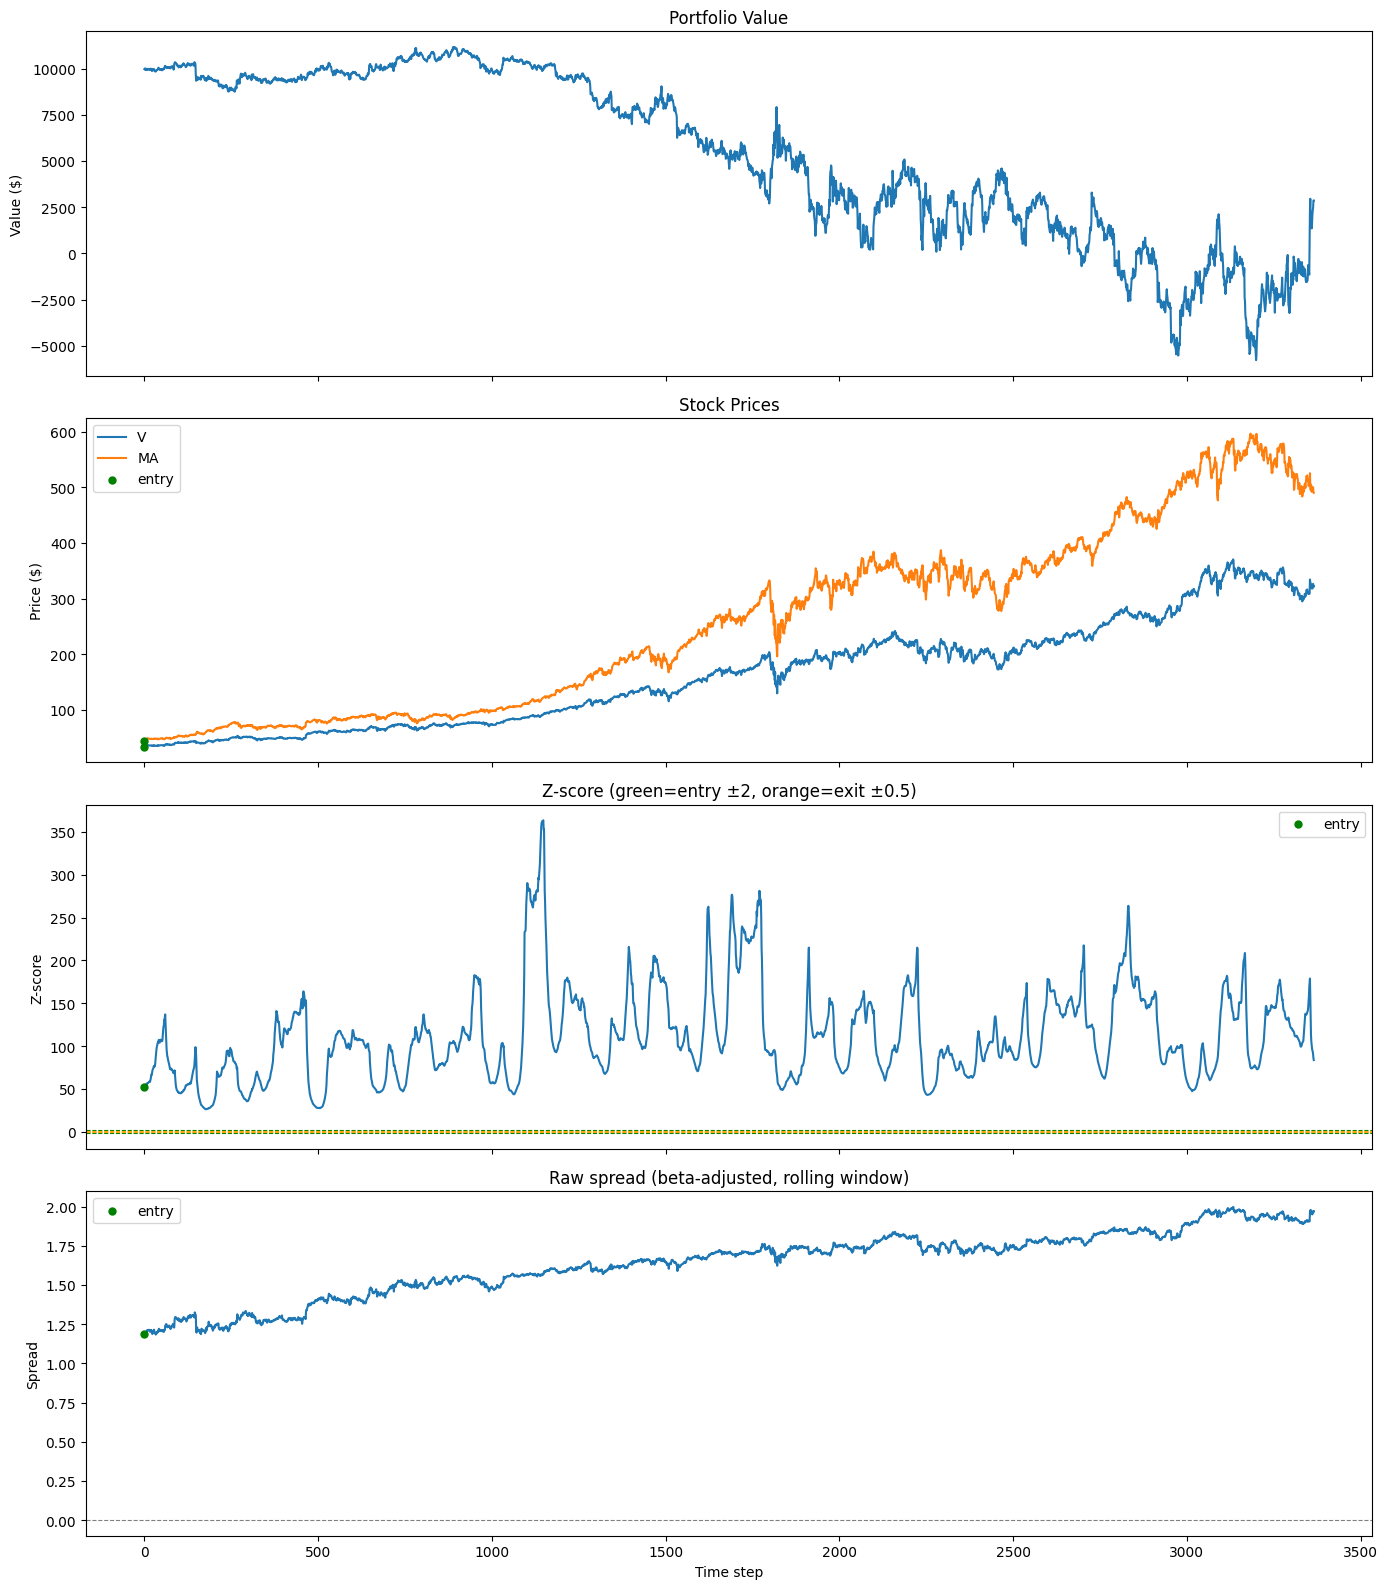

HD/LOW: β=2.0906


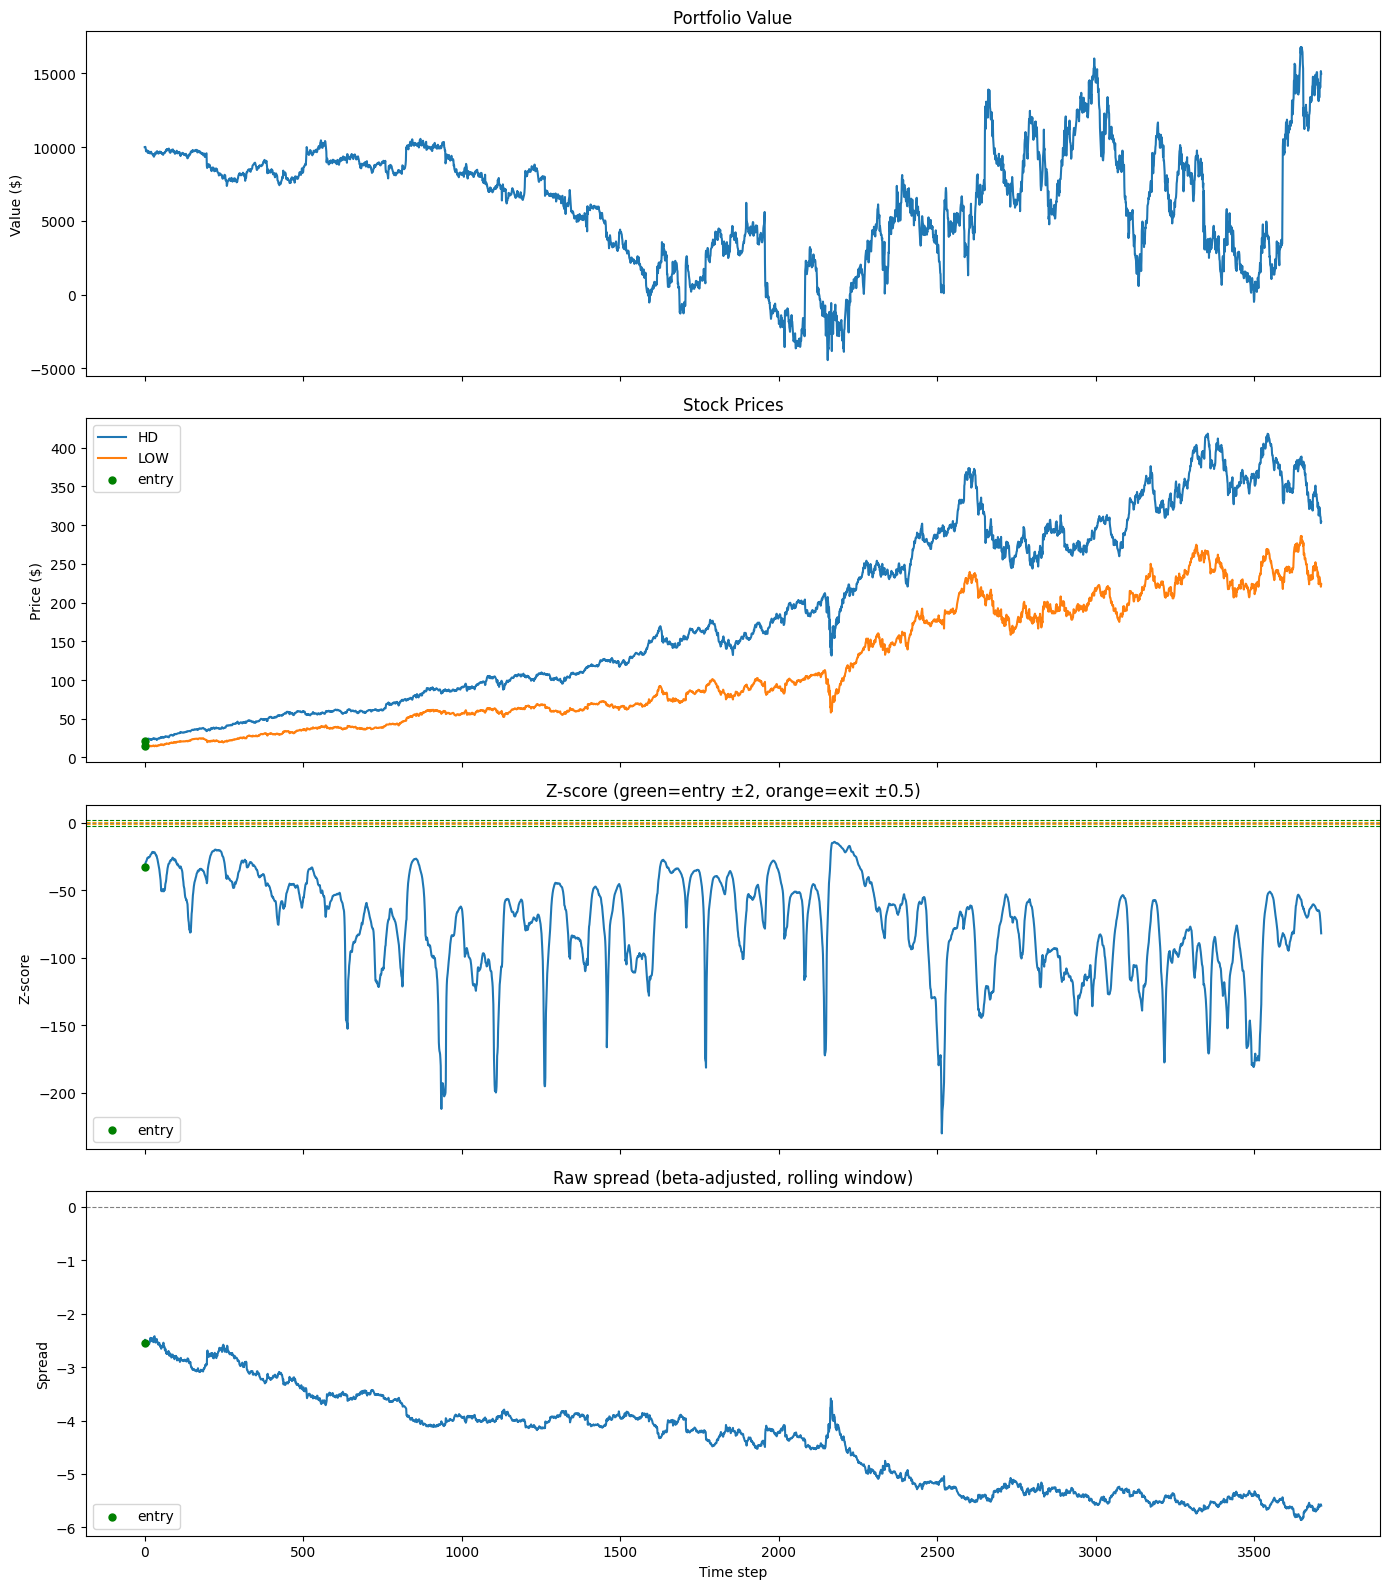

T/VZ: β=0.4146


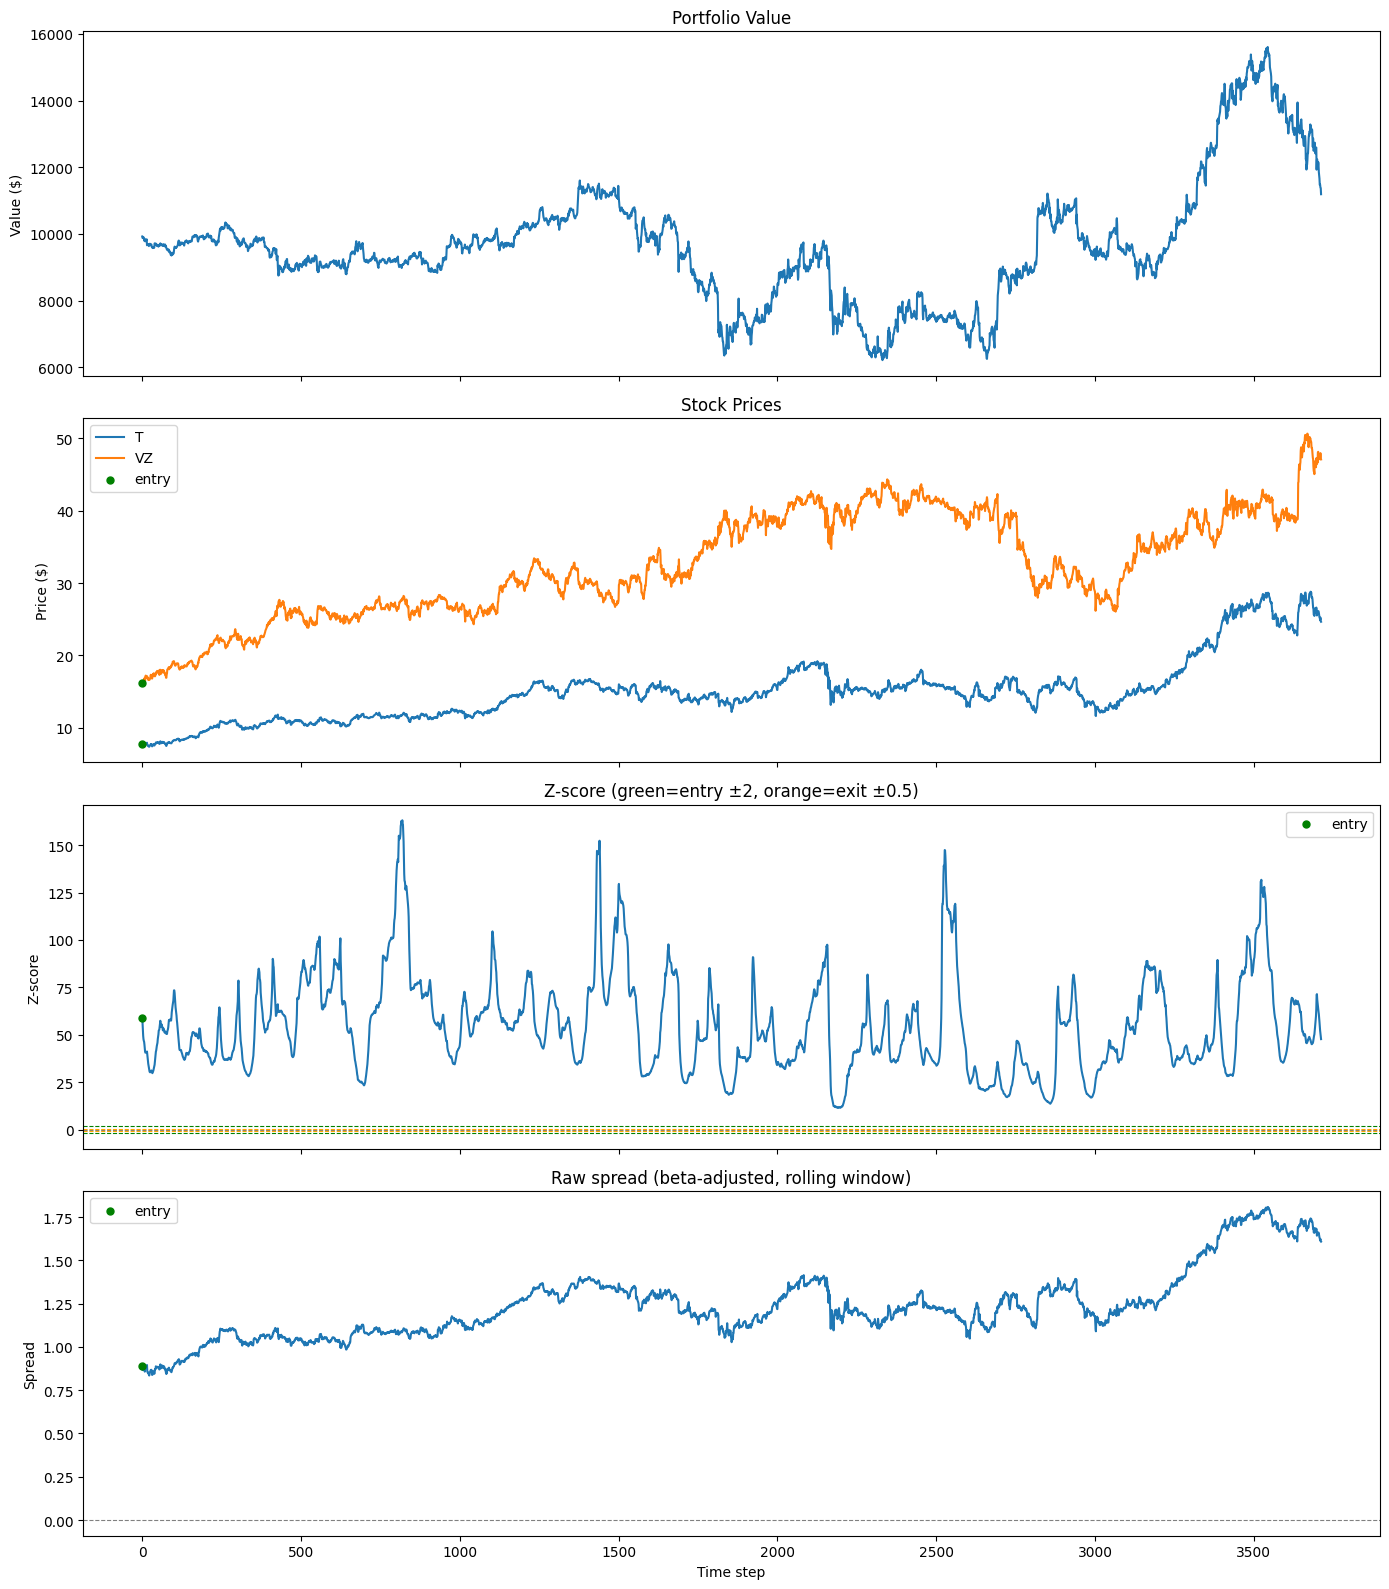

In [3]:
pairs = [
    ("MPC",  "PSX"),
    ("PEP",  "KO"),
    ("AAPL", "MSFT"),
    ("JPM",  "BAC"),
    ("XOM",  "CVX"),
    ("MCD",  "YUM"),
    ("GS",   "MS"),
    ("V",    "MA"),
    ("HD",   "LOW"),
    ("T",    "VZ"),
]

all_results = {}
for t1, t2 in pairs:
    data = PairData(f"../../data/real_pair_{t1}_{t2}.csv")
    all_results[f"{t1}/{t2}"] = run_johansen_fixed_beta(data)


MPC/PSX


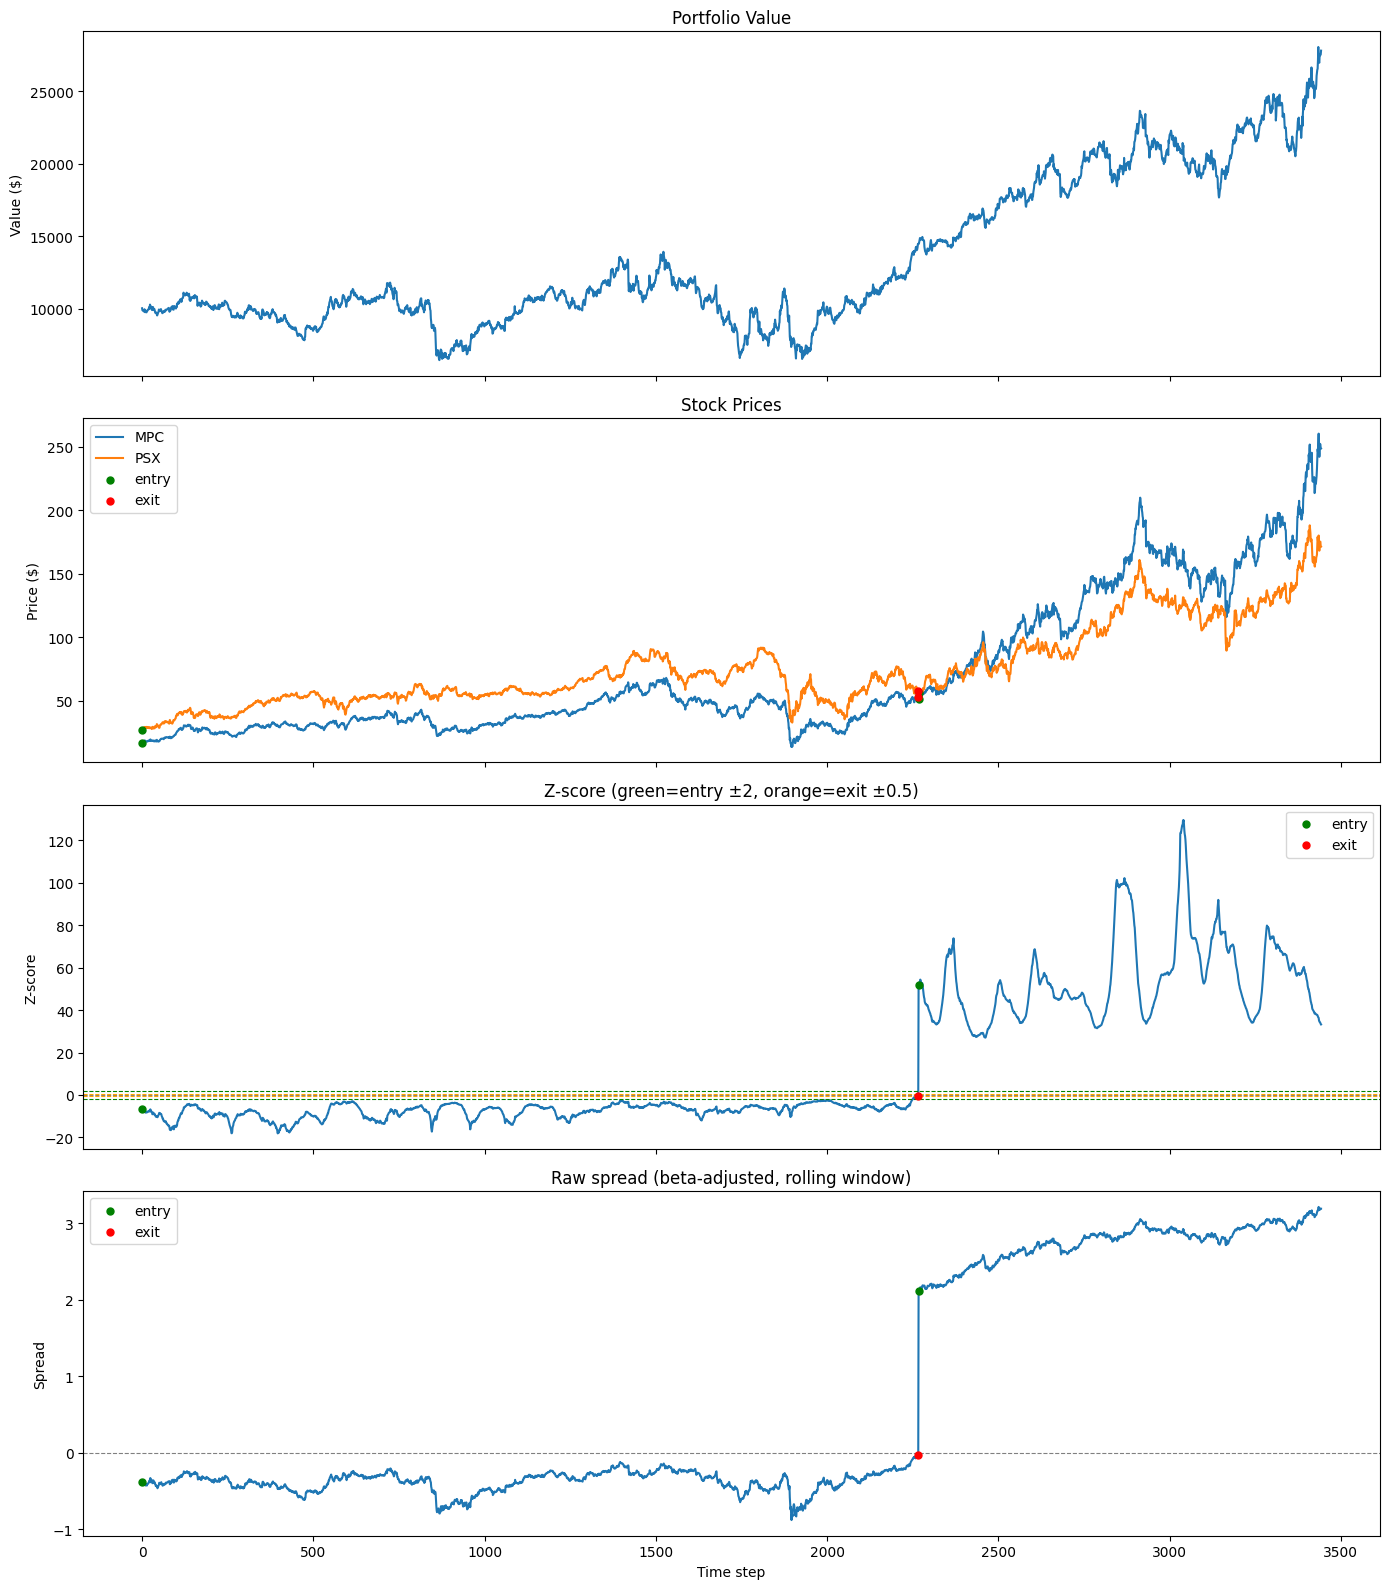

PEP/KO


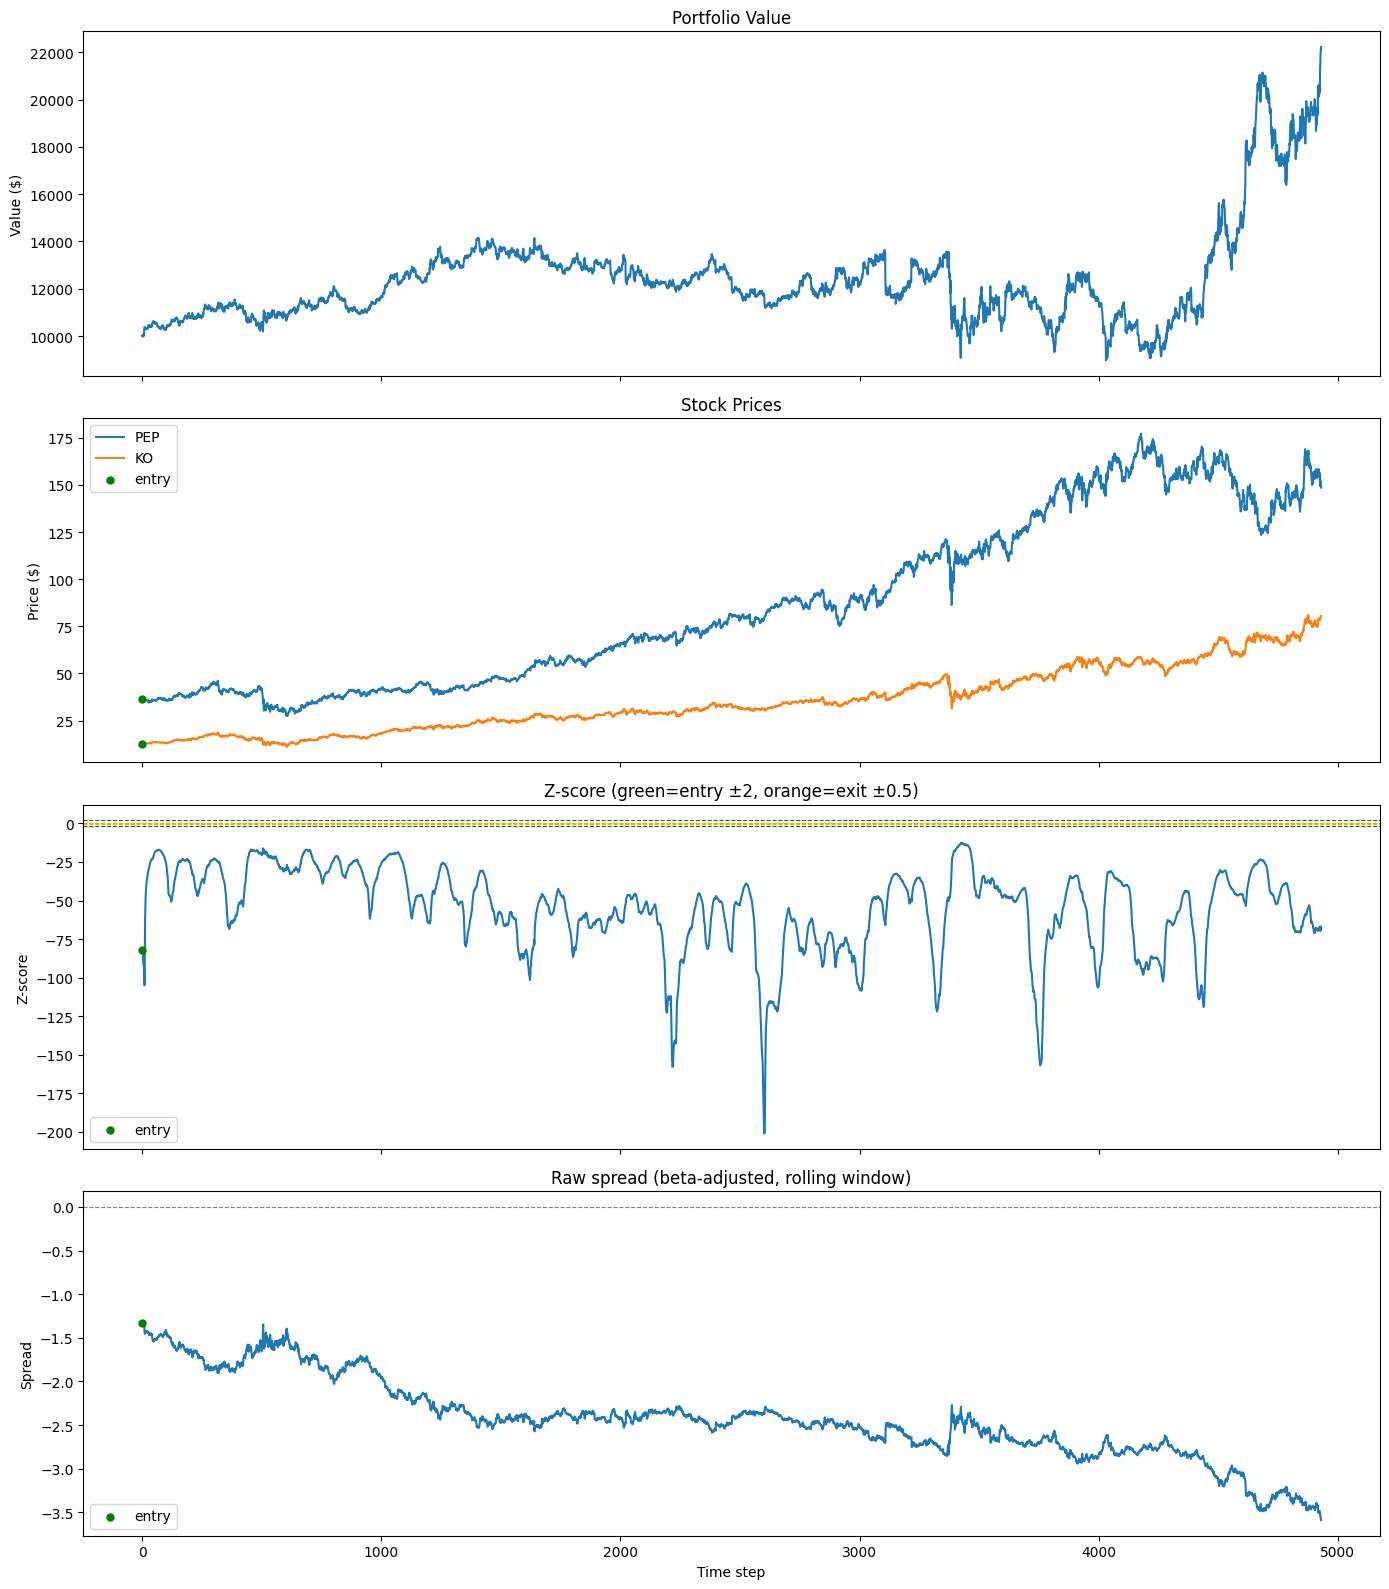

AAPL/MSFT


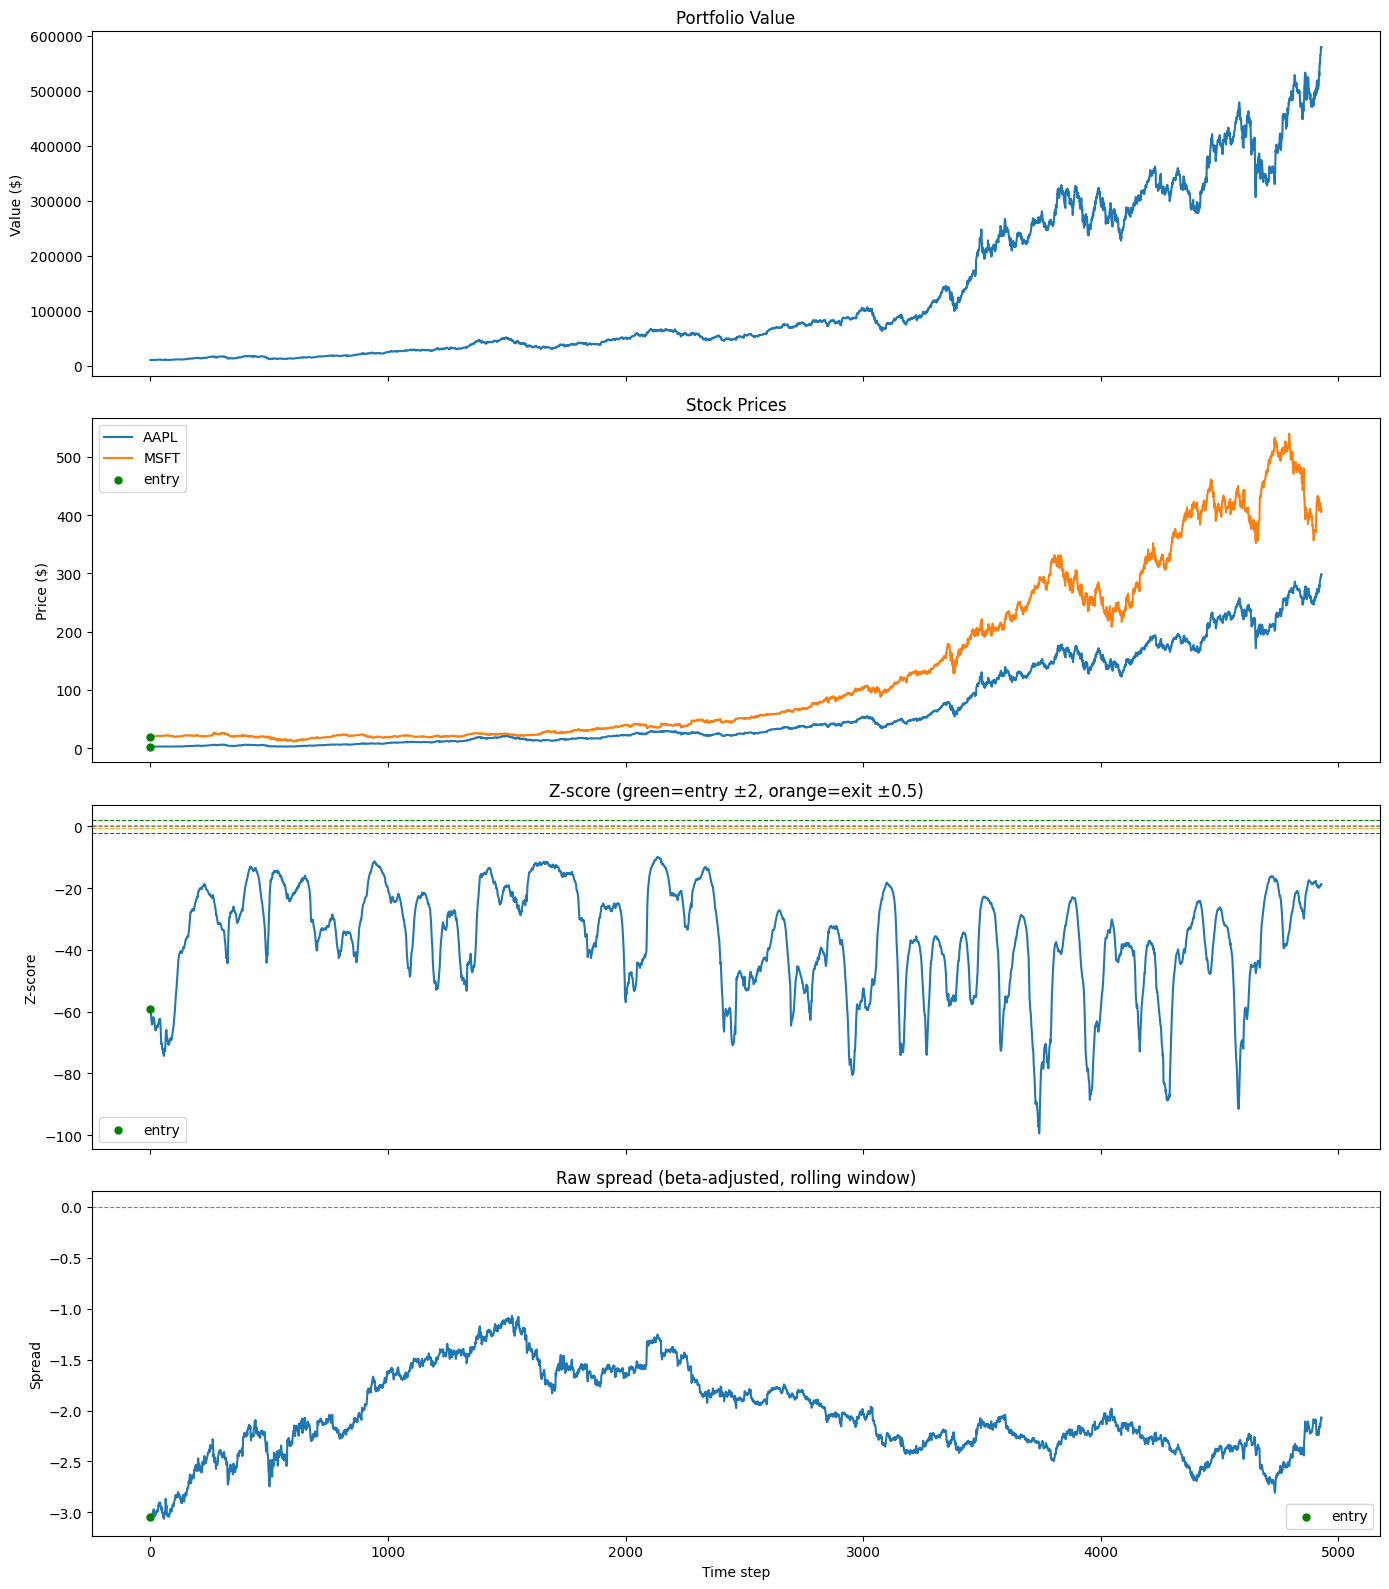

JPM/BAC


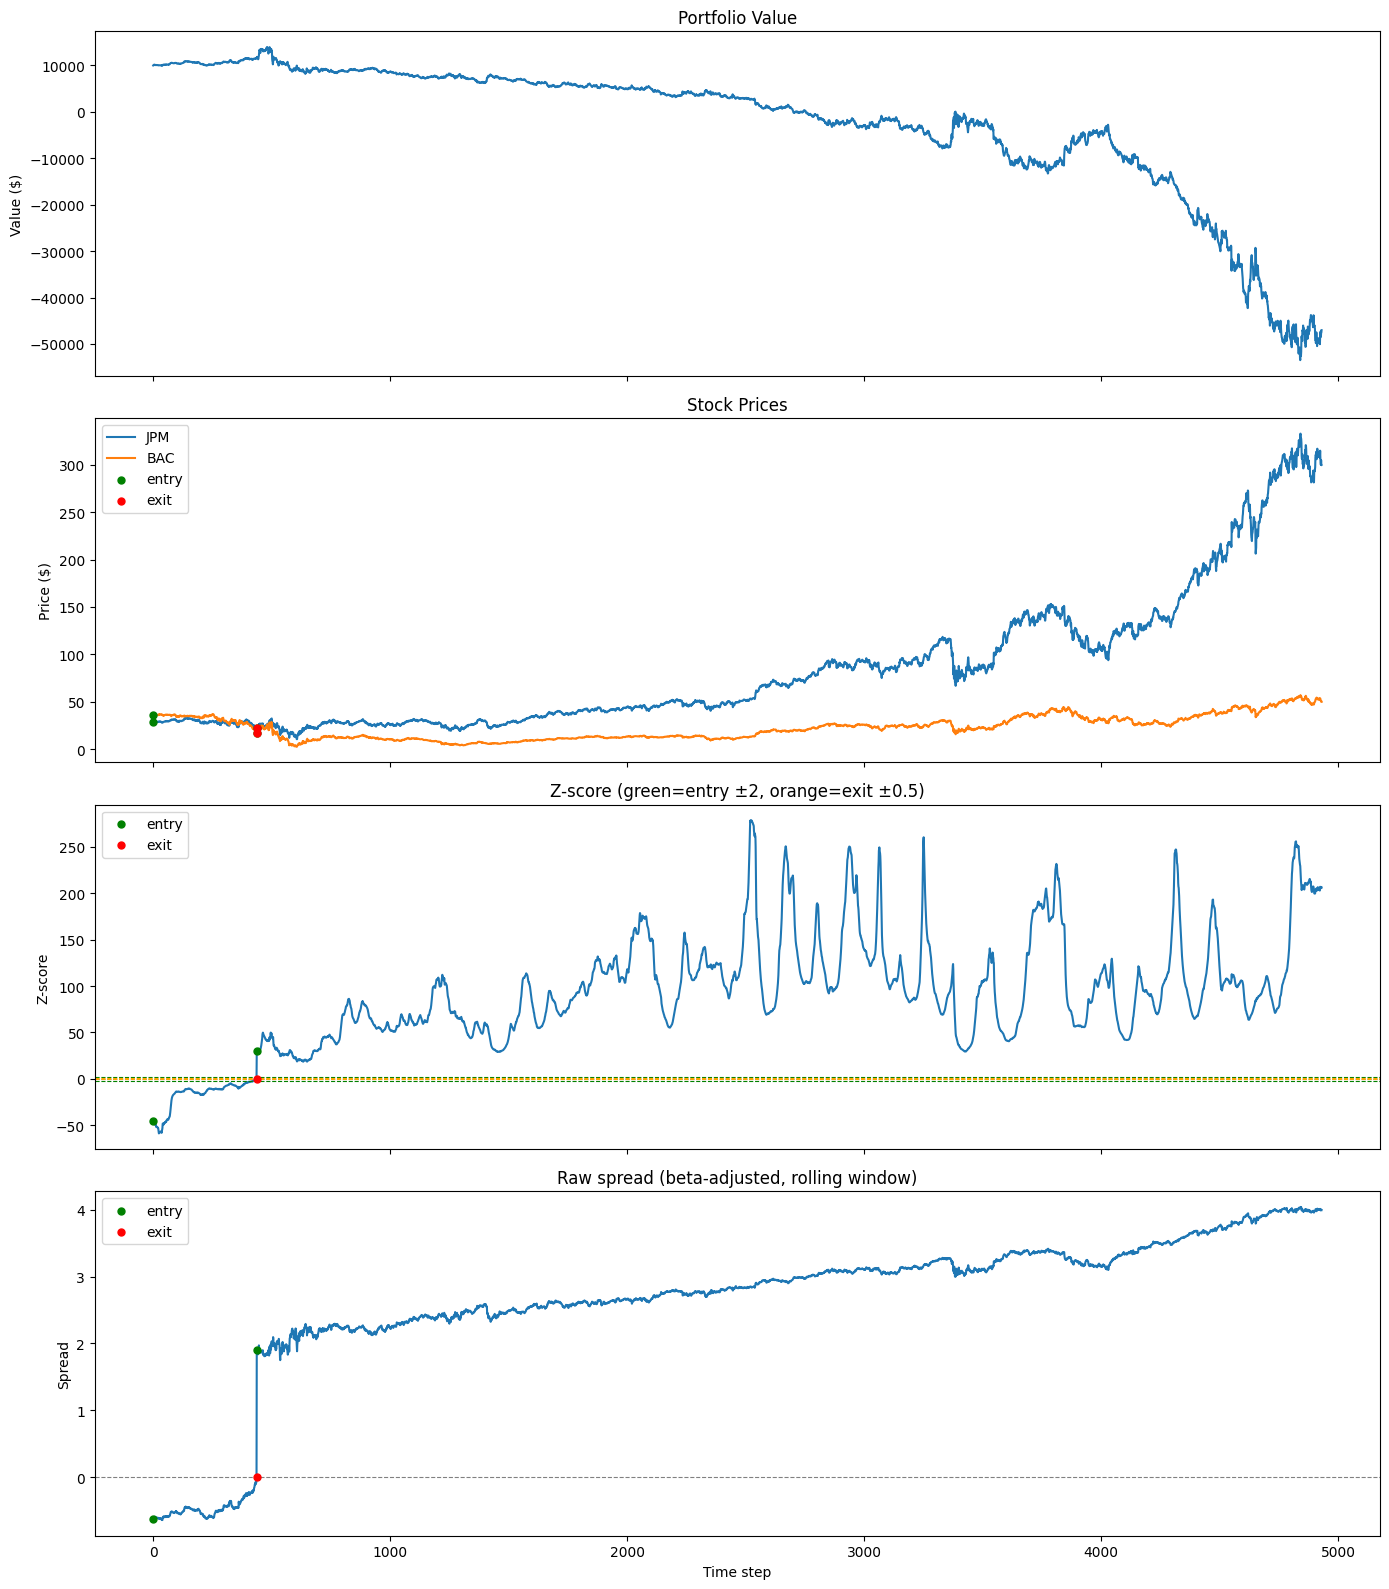

XOM/CVX


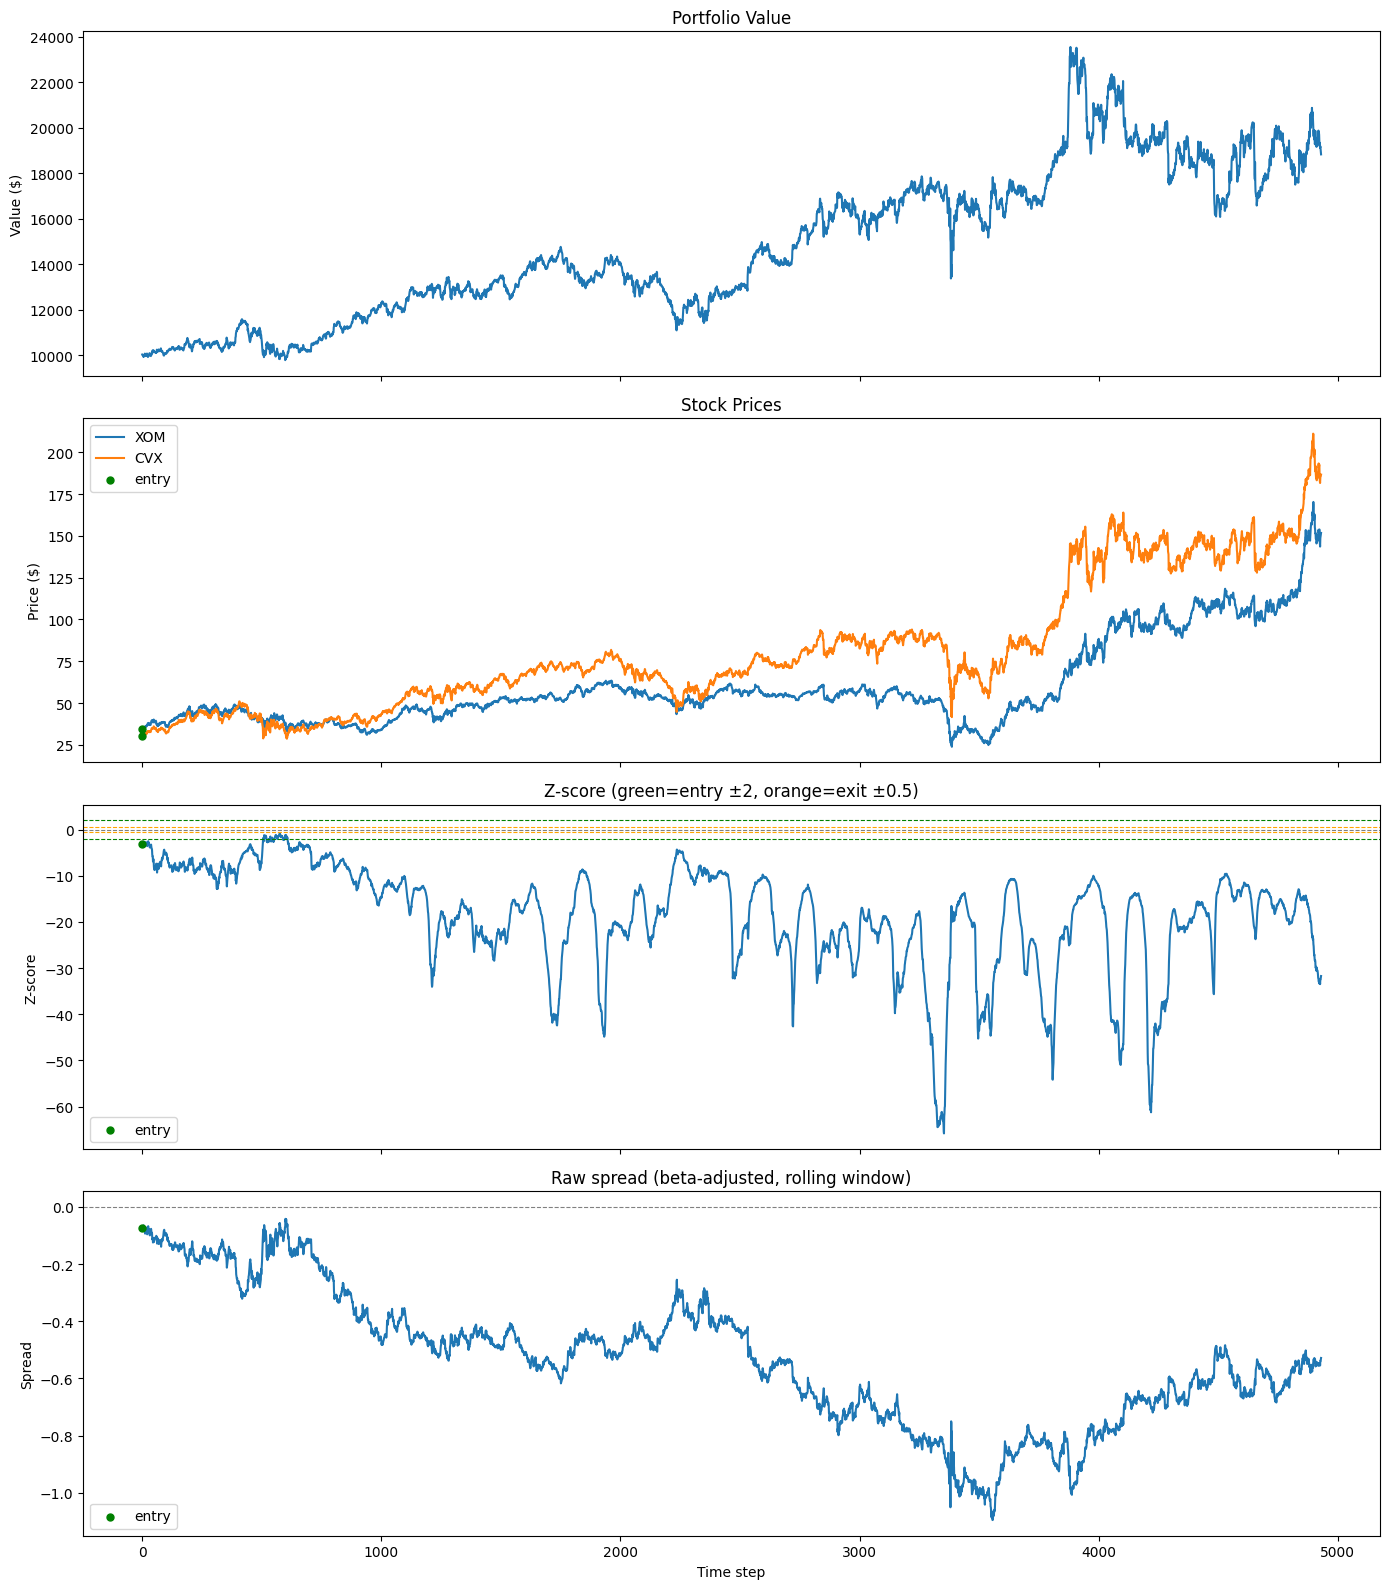

MCD/YUM


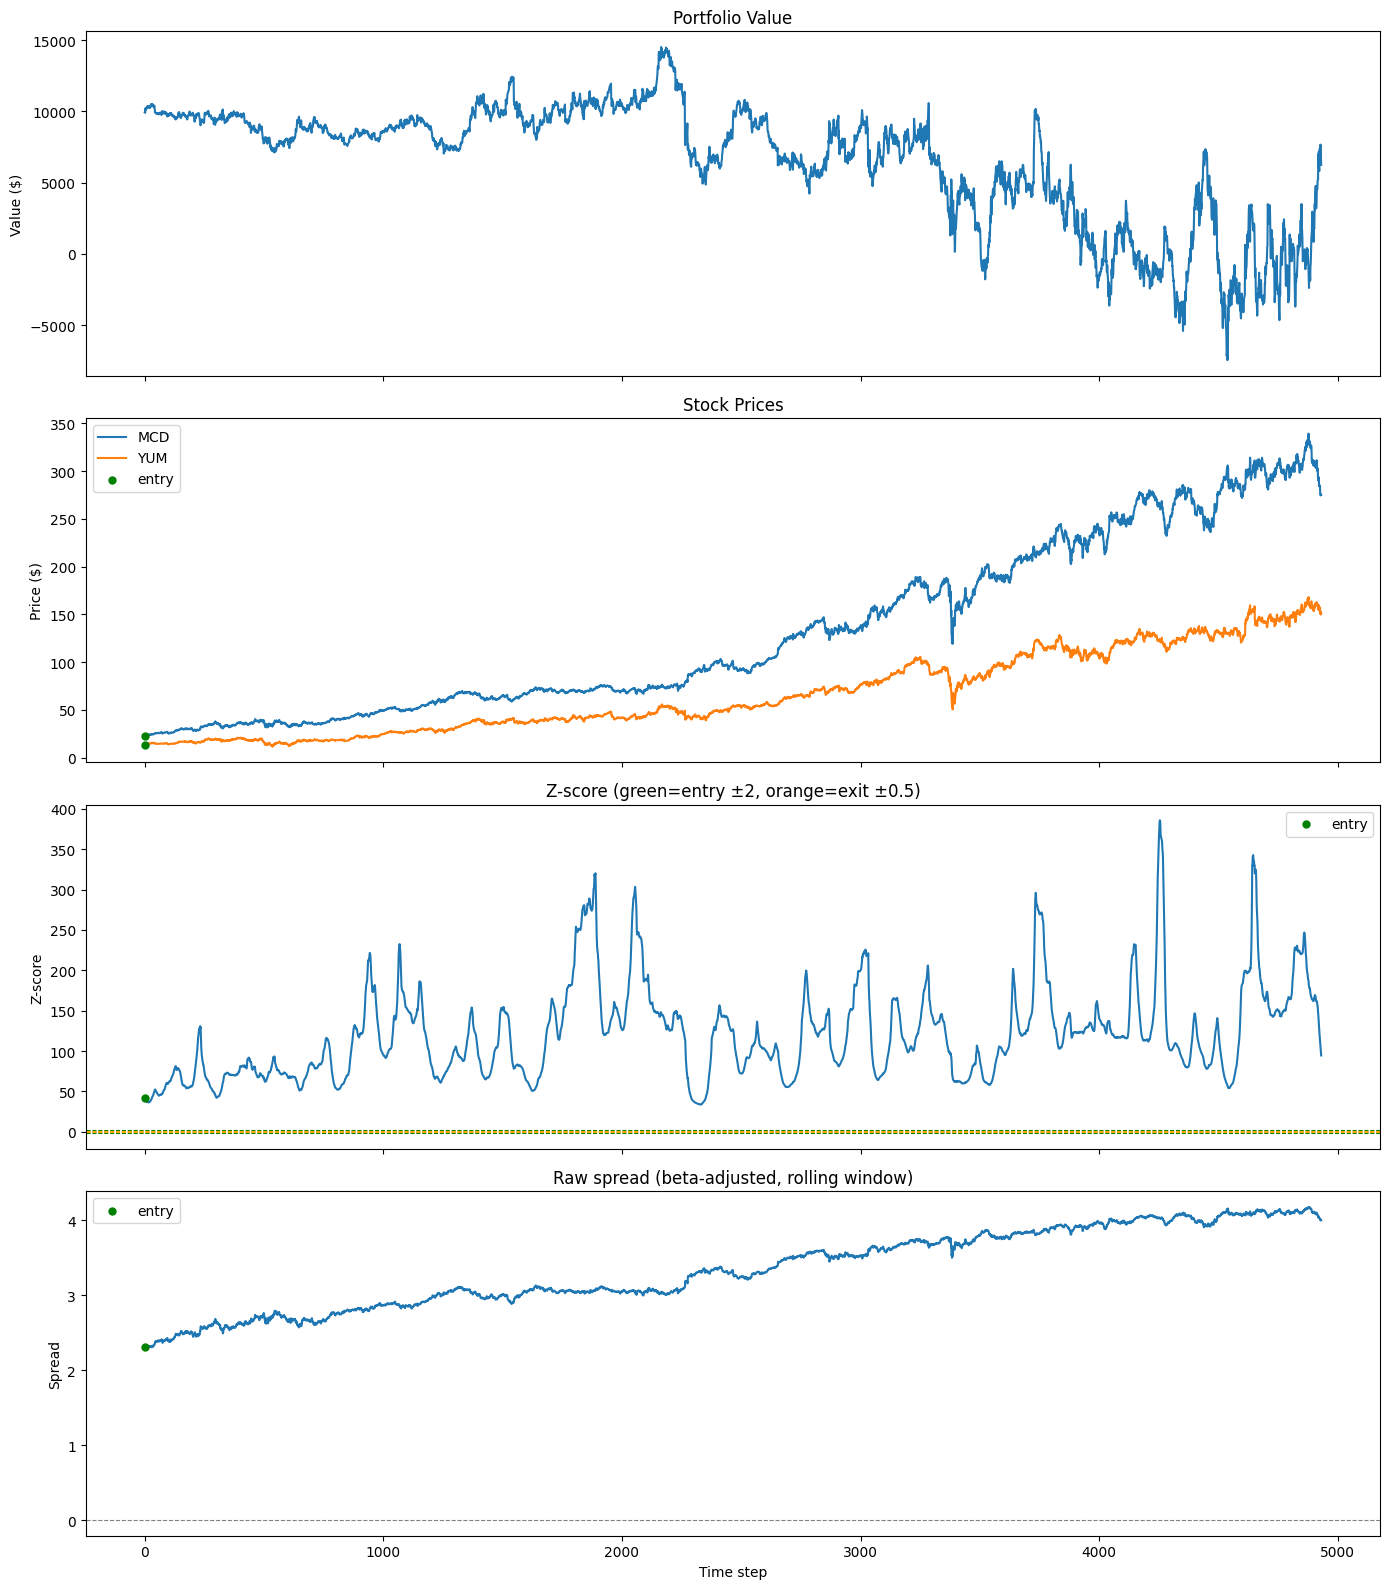

GS/MS


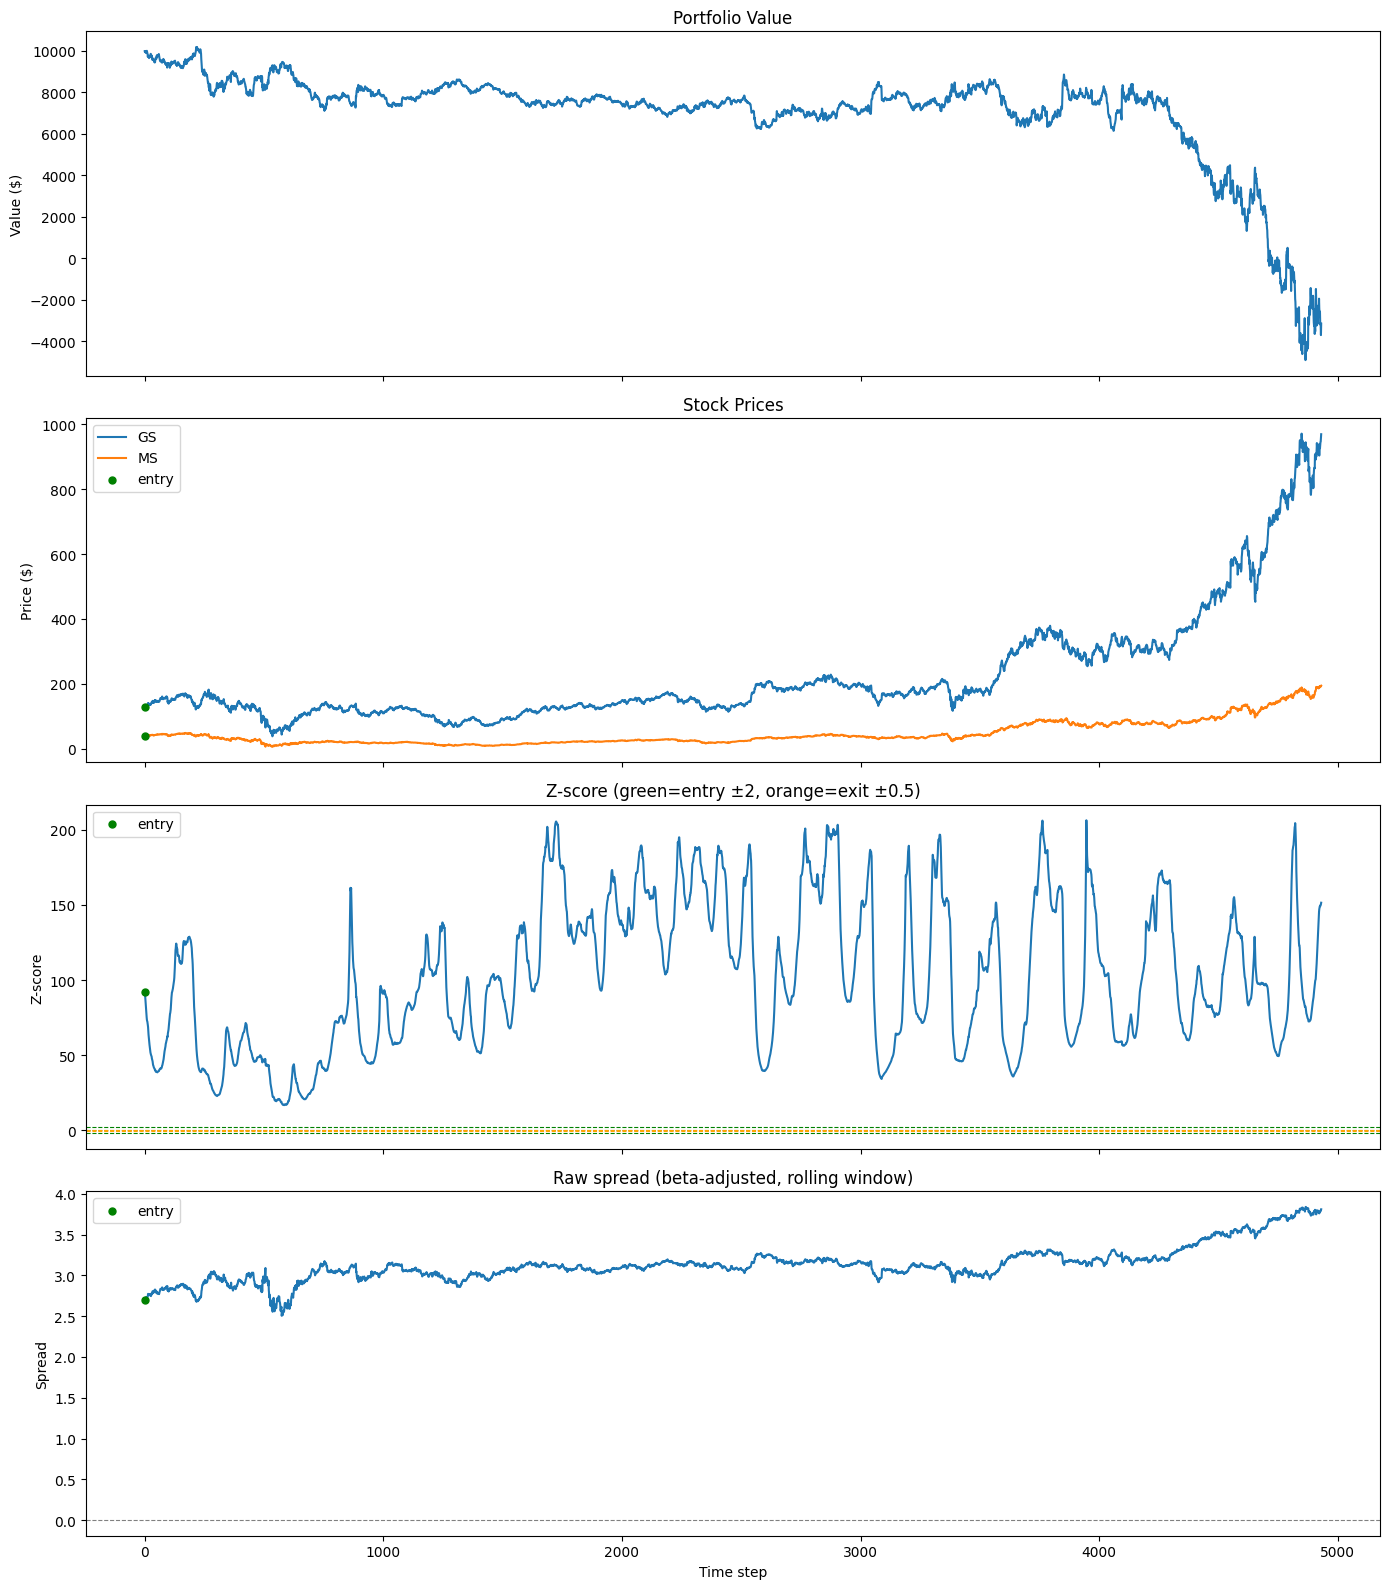

V/MA


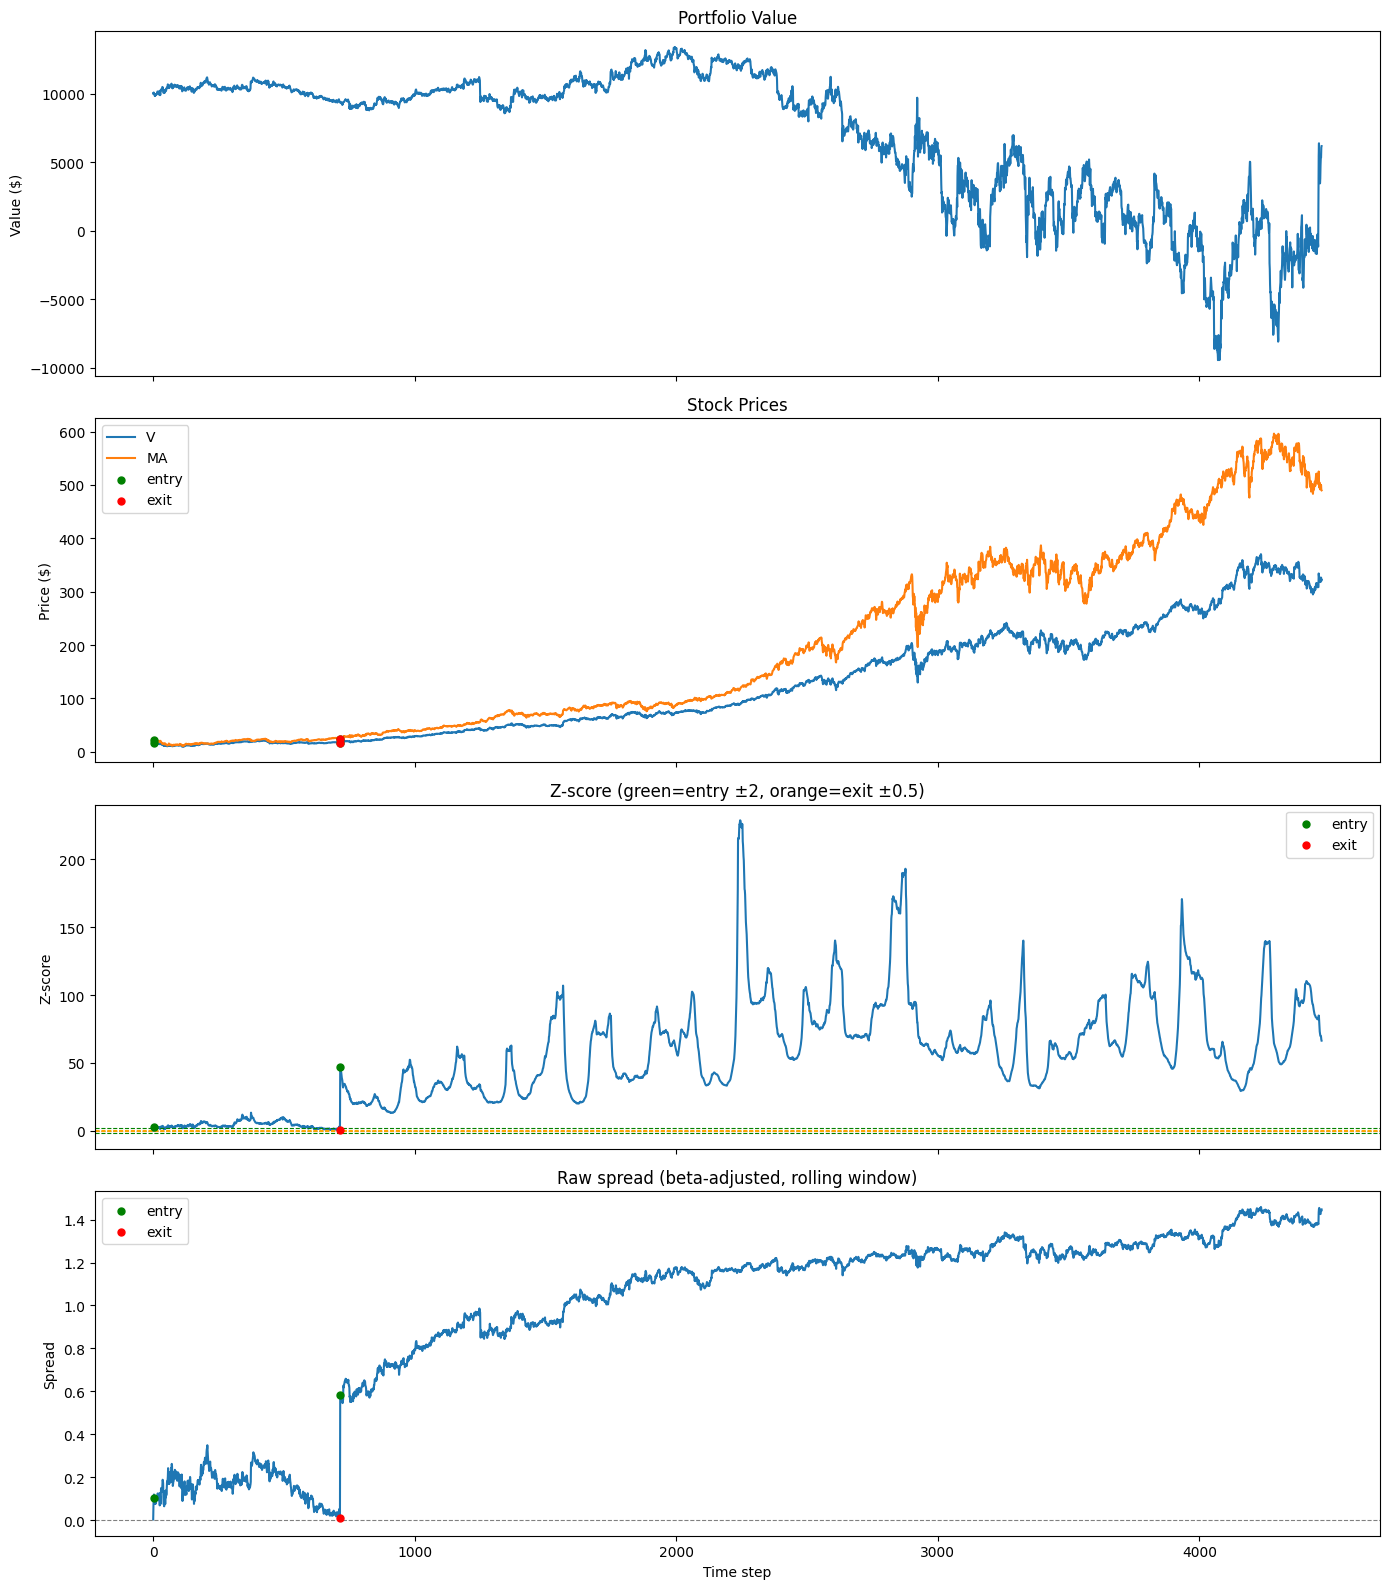

HD/LOW


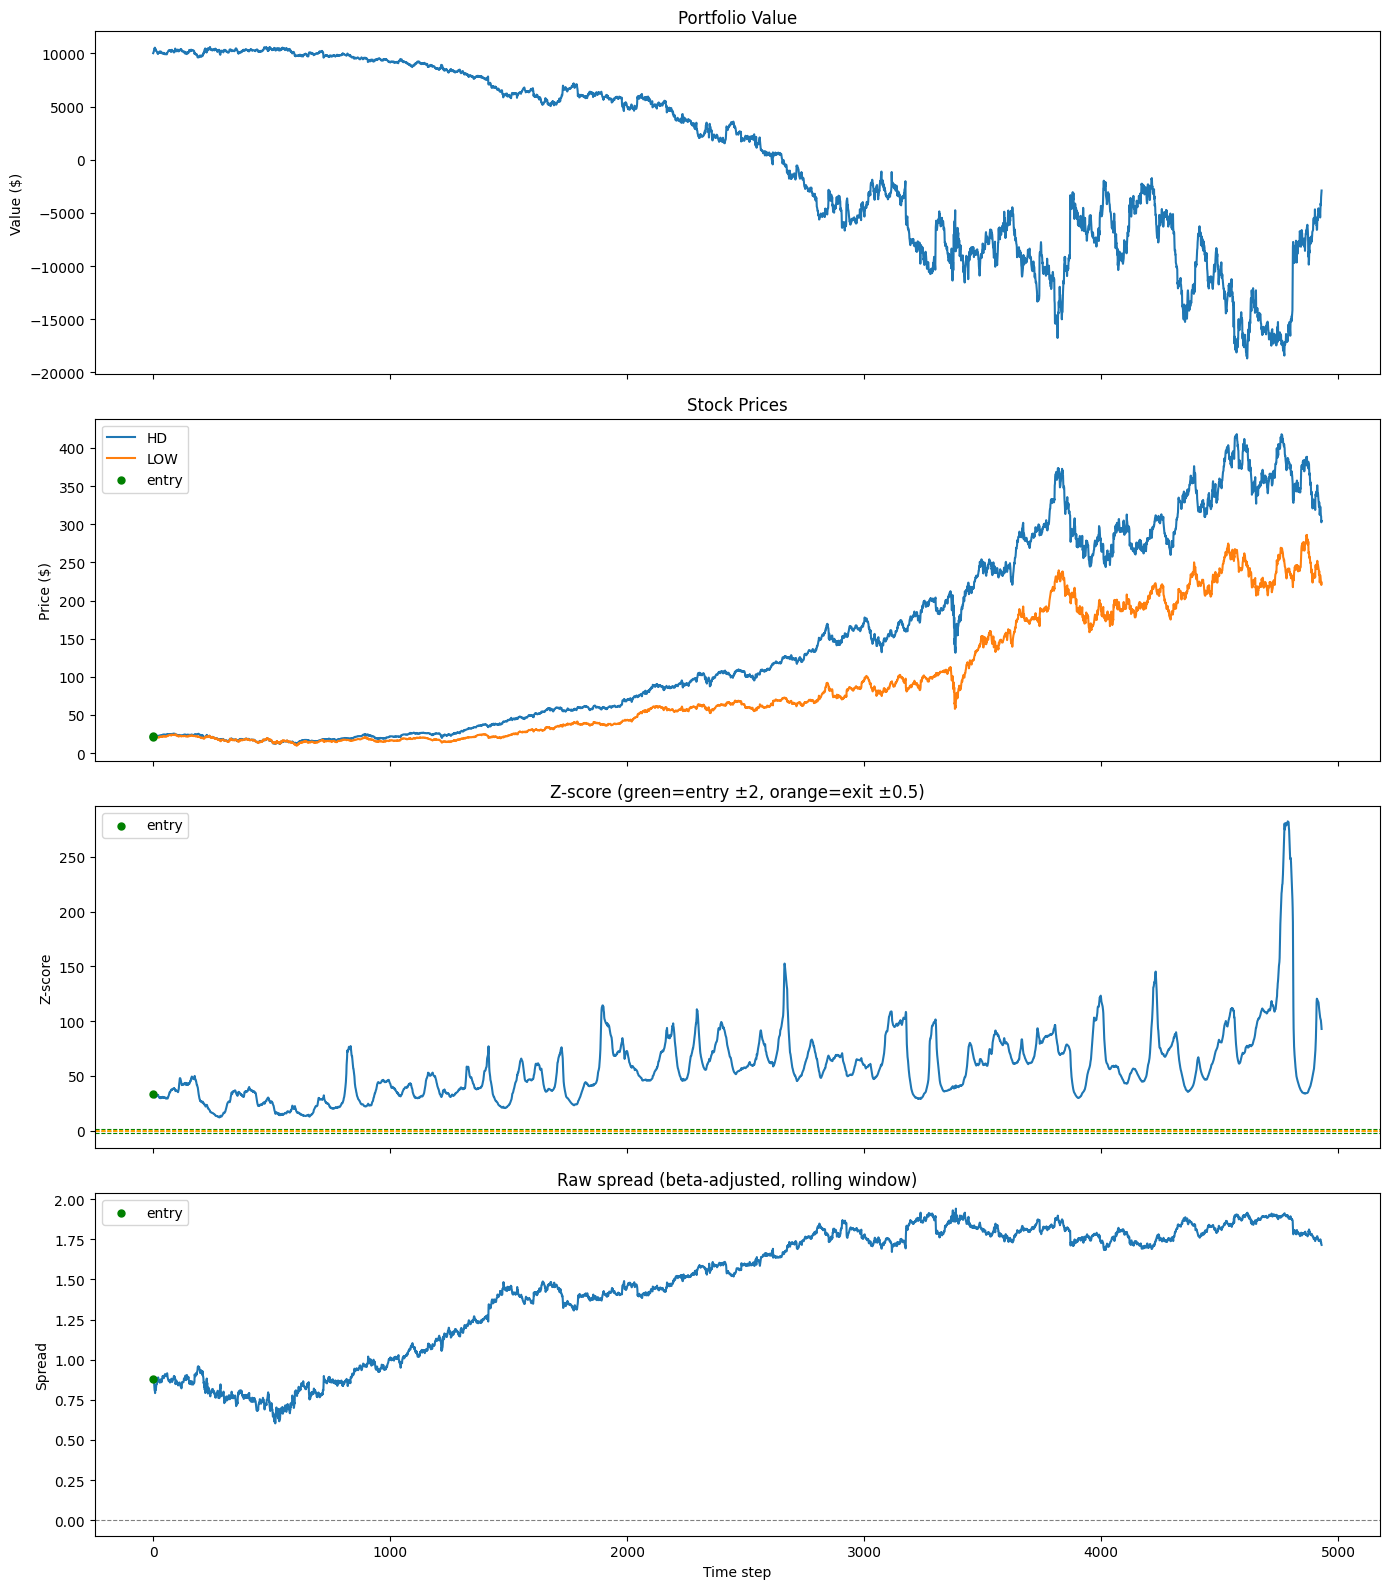

T/VZ


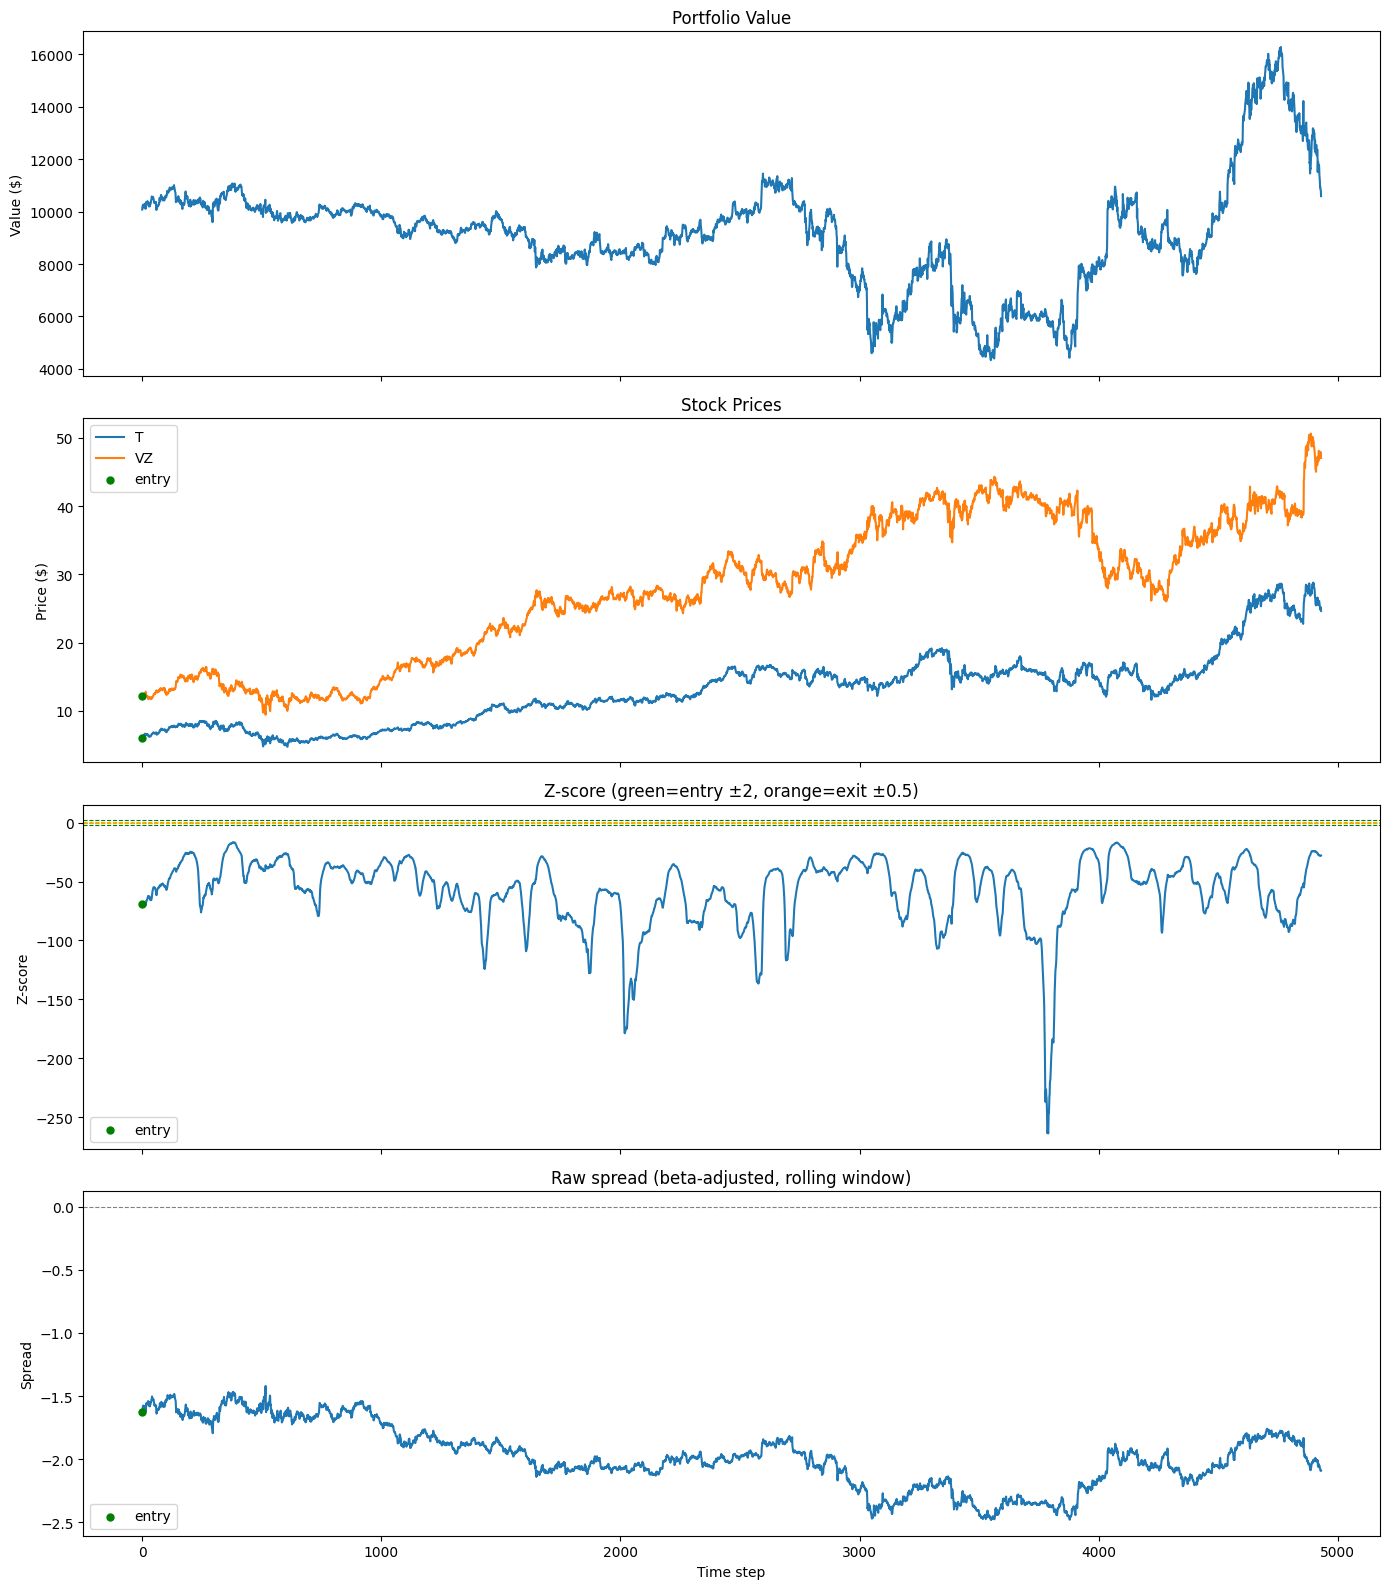

In [4]:
all_results_rolling = {}
for t1, t2 in pairs:
    data = PairData(f"../../data/real_pair_{t1}_{t2}.csv")
    env_rolling = Market(data, past_window=100)
    results = run_strategy(env_rolling, ZScoreBaseline(entry_threshold=2.0, exit_threshold=0.5))
    print(f"{t1}/{t2}")
    plot_strategy(results)
    all_results_rolling[f"{t1}/{t2}"] = results


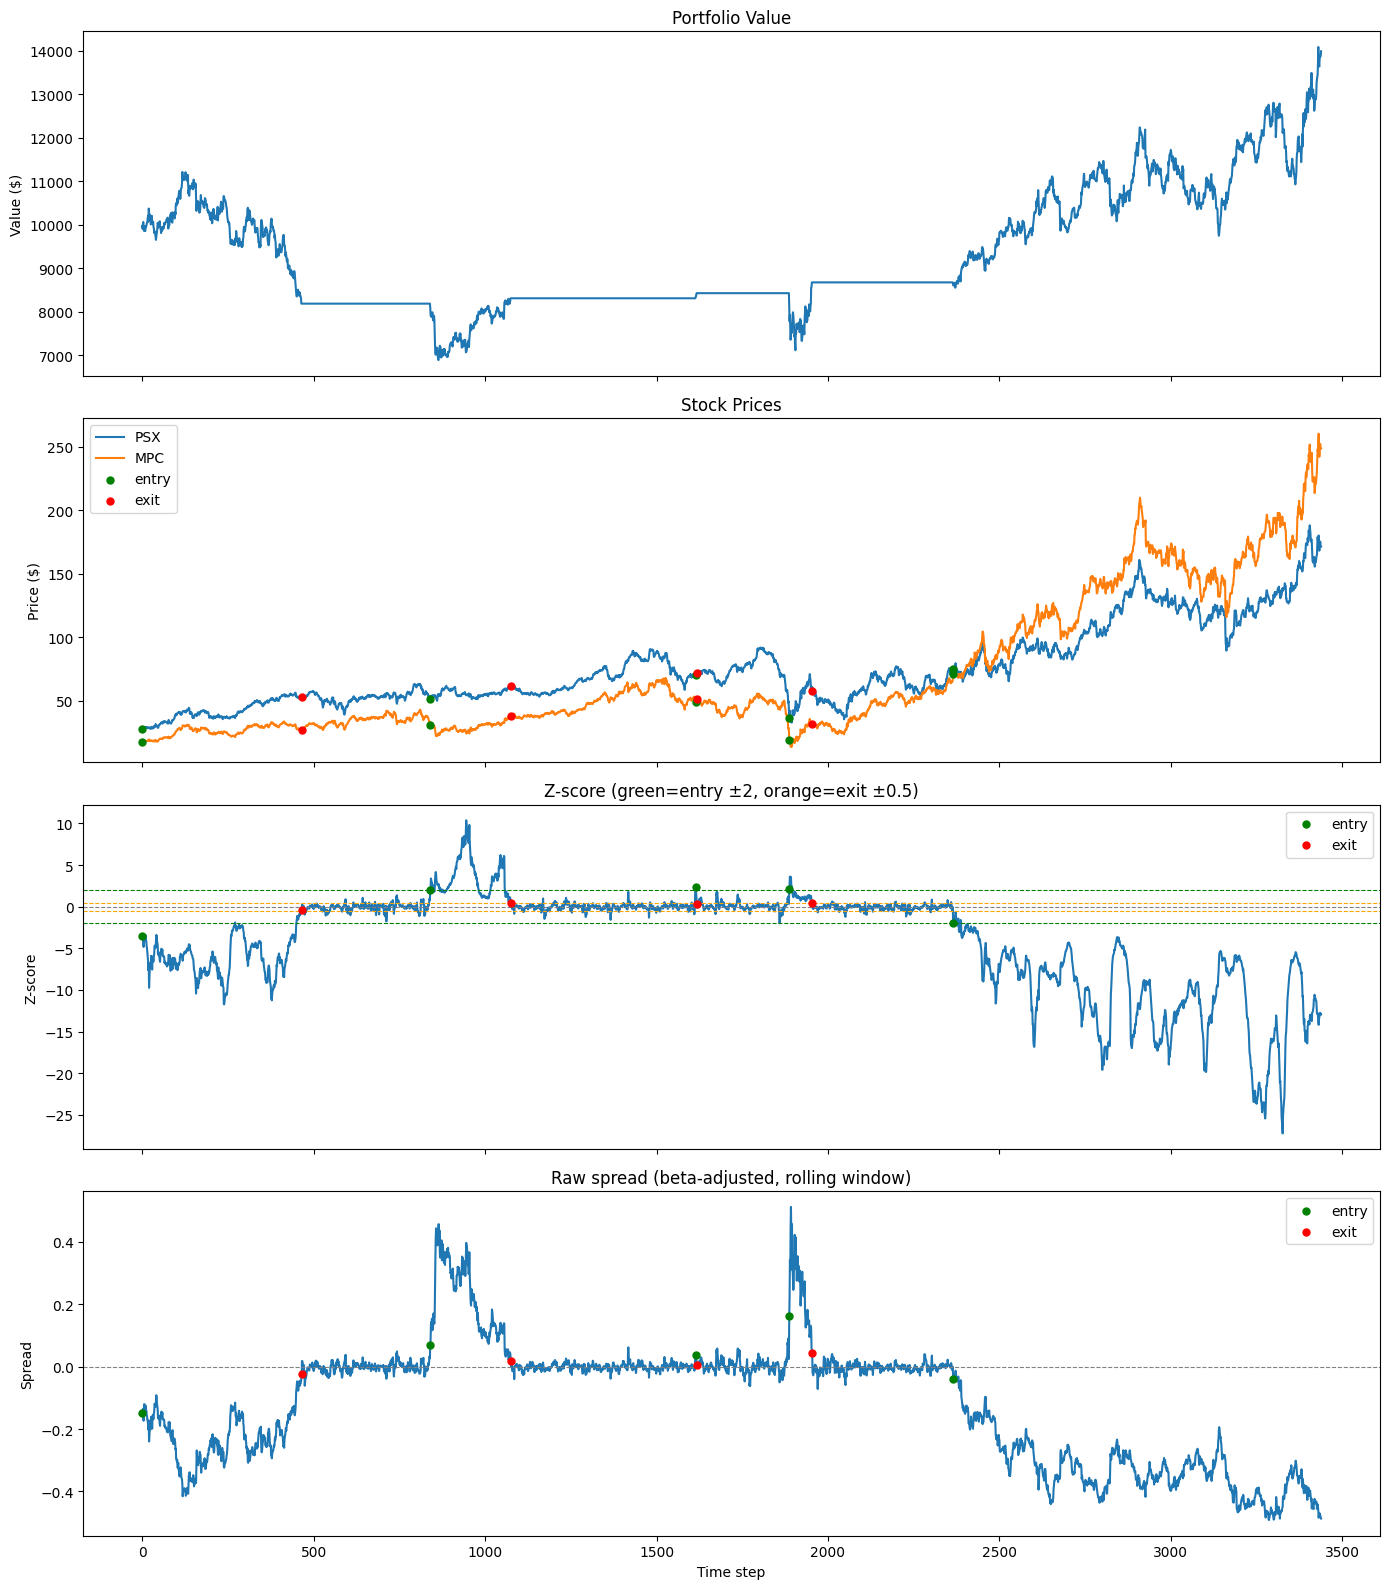

In [5]:
env_kf = Market(pair_data, use_kalman=True, kf_Q=1e-5, kf_R=1e-3)
results_kf = run_strategy(env_kf, ZScoreBaseline(entry_threshold=2.0, exit_threshold=0.5))
plot_strategy(results_kf)
